# 실험 로그

# 실험 로그

| 실험 | 모델 | Feature Engineering | 파라미터 | Score | 비고 |
|------|------|---------------------|----------|-------|------|
| 4/24(금)|
| exp1 | XGBoost | 기본 feature + 파생변수 110개 | lr=0.05, depth=6, subsample=0.8 | 0.7392 | |
| exp2 | Catboost | - | iterations=2000, lr=0.05, depth=6 | 0.7397 | |
| exp3 | XGBoost x Catboost 앙상블 | 기본 feature + 파생변수 110개 | iterations=2000, lr=0.05, depth=6  | 0.7399 | A. Simple Average (XGB : Cat = 1:1) |
| exp4 | - |  -  |  - | 0.7399 | B. Weighted Average(OOF AUC가 높은 모델 가중치 부여) |
| exp5 | - |  -  |  - | 0.7399 | C. Stacking (메타 모델 : LR) |
| exp6 | - |  -  |  - | 0.7399 | D. Rank Average(확률 대신 순위로 변환 후 평균) |
| exp7 | XGBoost | 기본 feature + 파생변수 110개 | XGB: depth=5 / Cat: depth=5  | 0.7397 |optuna|
| exp8 | Catboost | - | XGB: depth=5 / Cat: depth=5  | 0.7397 |optuna |
| exp7 | XGBoost x Catboost 앙상블(optuna) |  기본 feature + 파생변수 110개  | XGB: depth=5 / Cat: depth=5 | 0.7399 | A. Simple Average (XGB : Cat = 1:1) |
| exp8 | - |  -  |  - | 0.7399 | B. Weighted Average(OOF AUC가 높은 모델 가중치 부여) |
| exp9 | - |  -  |  - | 0.7399 | C. Stacking (메타 모델 : LR) |
| exp10 | - |  -  |  - | 0.7399 | D. Rank Average(확률 대신 순위로 변환 후 평균) 리더보드 점수 : 0.74162 |
| 4/25(토) |
| exp11 | LGBM x XGBoost x Catboost 앙상블(optuna) |  기본 feature + 파생변수 110개  | LGBM : max_depth=3 / XGB: max_depth=5 / Cat: depth=6 | 0.7400 | 리더보드 점수 :  0.74140  |

In [3]:
! pip install optuna lightgbm catboost -q


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)  # 불필요한 로그 제거

In [6]:
# 한글 폰트 설정
! pip install koreanize-matplotlib -q

try:
    import koreanize_matplotlib
except ImportError:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [7]:
#시드 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [8]:
TARGET = "임신 성공 여부"
ID_COL = "ID"
DATA_DIR = Path(".")   # 데이터 경로 수정

SEED = 42

In [17]:
train = pd.read_csv('../data/train.csv', encoding="utf-8-sig")
test  = pd.read_csv('../data/test.csv',  encoding="utf-8-sig")
sample_submission = pd.read_csv('../data/sample_submission.csv', encoding="utf-8-sig")

train.columns = [c.strip() for c in train.columns]
test.columns  = [c.strip() for c in test.columns]

df = train.copy()   # EDA용 원본 복사본

print(f"  Train shape : {train.shape}")
print(f"  Test  shape : {test.shape}")
print(f"\n  타겟 분포:\n{train[TARGET].value_counts()}")
print(f"\n  양성 비율: {train[TARGET].mean():.4f}")

  Train shape : (256351, 69)
  Test  shape : (90067, 68)

  타겟 분포:
임신 성공 여부
0    190123
1     66228
Name: count, dtype: int64

  양성 비율: 0.2583


단변량 분석

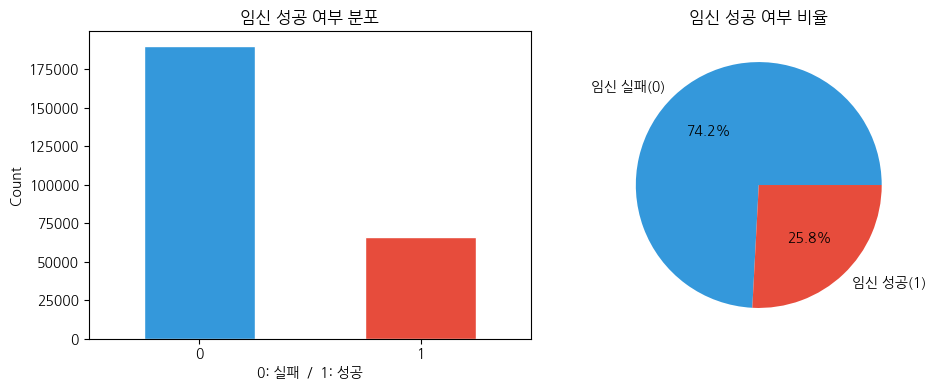

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
train[TARGET].value_counts().plot(
    kind="bar", ax=axes[0],
    color=["#3498db", "#e74c3c"], edgecolor="white"
)
axes[0].set_title("임신 성공 여부 분포")
axes[0].set_xlabel("0: 실패  /  1: 성공")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

train[TARGET].value_counts().plot(
    kind="pie", ax=axes[1],
    labels=["임신 실패(0)", "임신 성공(1)"],
    autopct="%1.1f%%", colors=["#3498db", "#e74c3c"]
)
axes[1].set_title("임신 성공 여부 비율")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


  전처리 전 결측치 현황 (Train)  (결측 컬럼: 31개 / 전체: 67개)
  🔴 난자 해동 경과일                        254,915건   99.4%  float64     컬럼 제거
  🔴 PGS 시술 여부                        254,422건   99.2%  float64     컬럼 제거
  🔴 PGD 시술 여부                        254,172건   99.1%  float64     컬럼 제거
  🔴 착상 전 유전 검사 사용 여부                 253,633건   98.9%  float64     컬럼 제거
  🔴 임신 시도 또는 마지막 임신 경과 연수            246,981건   96.3%  float64     컬럼 제거
  🔴 배아 해동 경과일                        215,982건   84.3%  float64     컬럼 제거
  🟠 난자 채취 경과일                        57,488건   22.4%  float64     중앙값 대체
  🟠 난자 혼합 경과일                        53,735건   21.0%  float64     중앙값 대체
  🟡 배아 이식 경과일                        43,566건   17.0%  float64     중앙값 대체
  🟡 총 생성 배아 수                         6,291건    2.5%  float64     중앙값 대체
  🟡 기증자 정자와 혼합된 난자 수                  6,291건    2.5%  float64     중앙값 대체
  🟡 단일 배아 이식 여부                       6,291건    2.5%  float64     중앙값 대체
  🟡 착상 전 유전 진단 사용 여부                  6,291건    2.5%  float64     중앙값 대체
  🟡

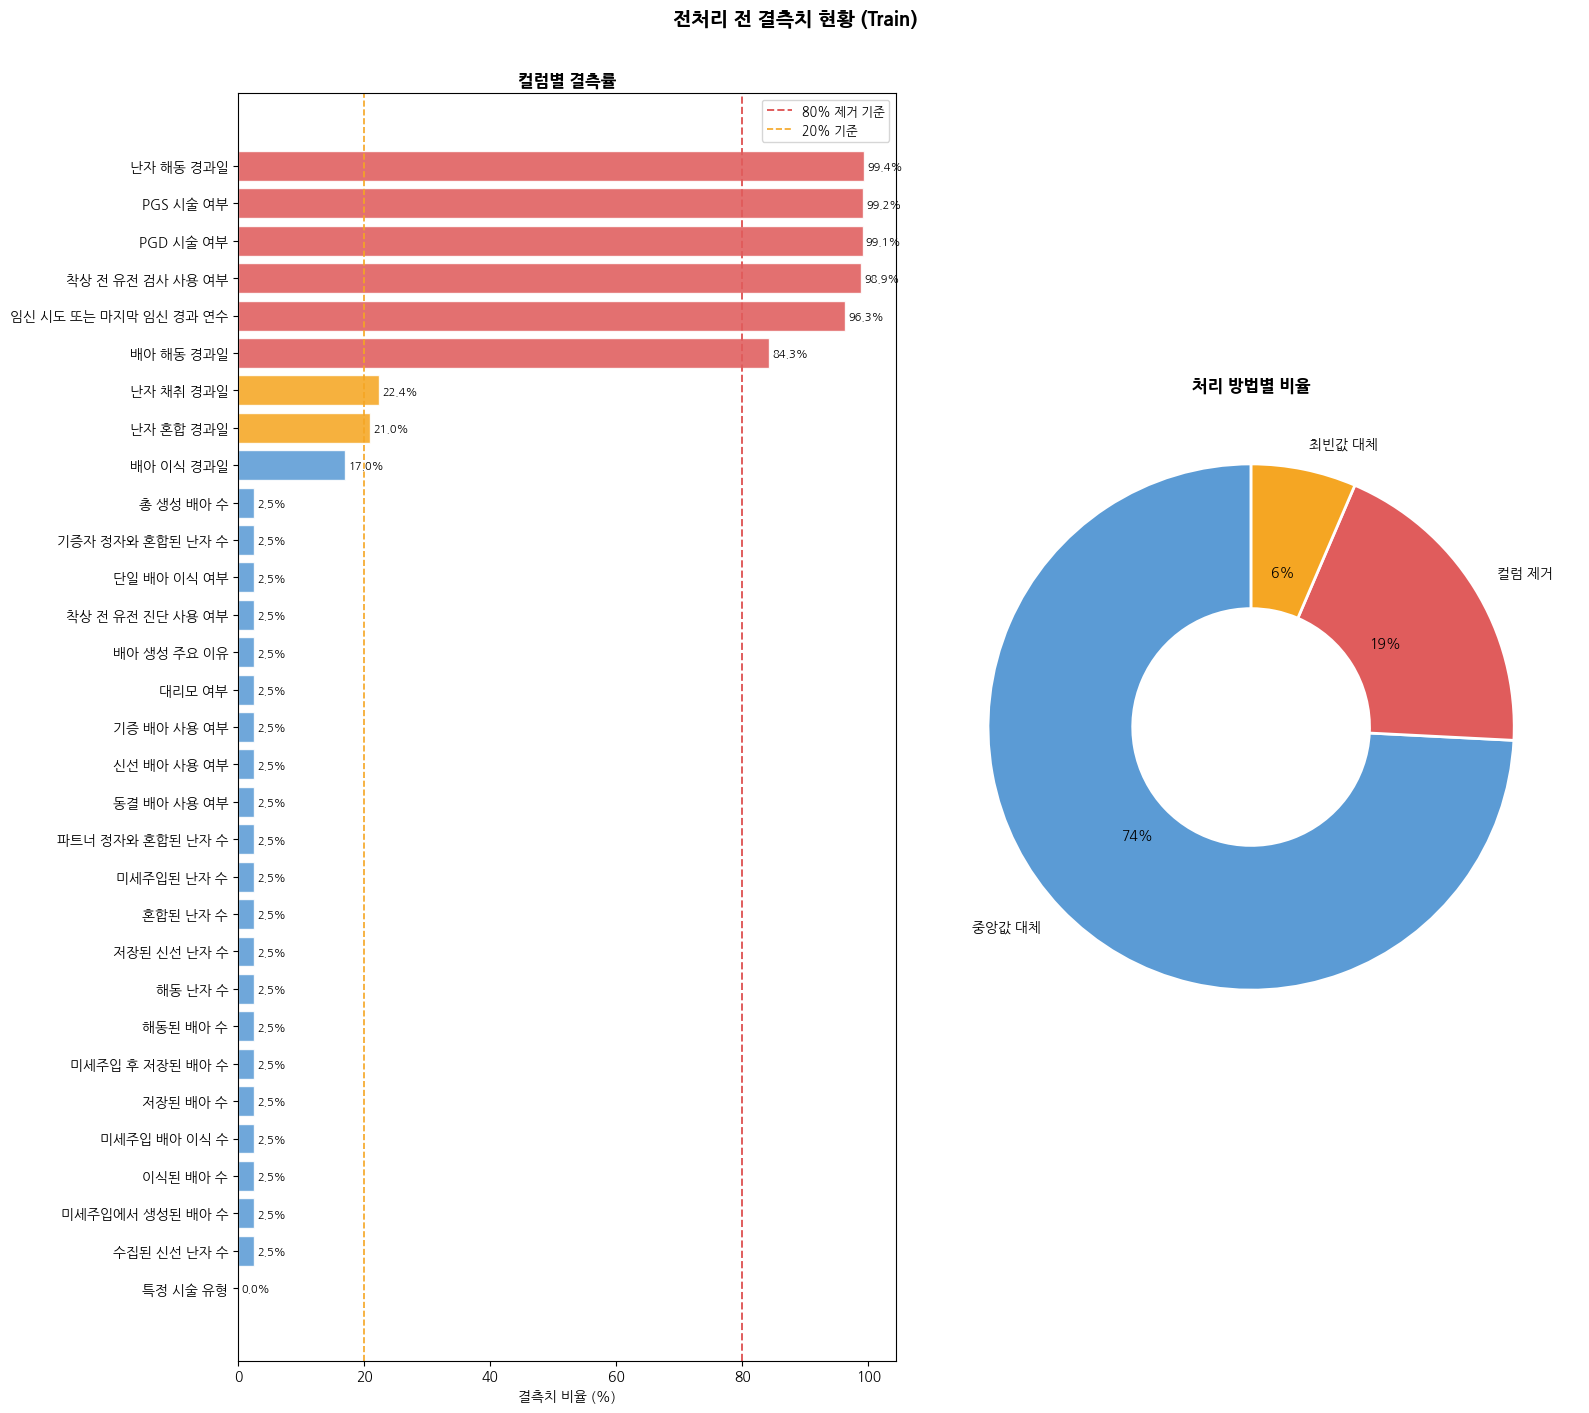

,컬럼명,결측 수,결측률(%),타입,처리 방법
0,난자 해동 경과일,254915,99.4,float64,컬럼 제거
1,PGS 시술 여부,254422,99.2,float64,컬럼 제거
2,PGD 시술 여부,254172,99.1,float64,컬럼 제거
3,착상 전 유전 검사 사용 여부,253633,98.9,float64,컬럼 제거
4,임신 시도 또는 마지막 임신 경과 연수,246981,96.3,float64,컬럼 제거
5,배아 해동 경과일,215982,84.3,float64,컬럼 제거
6,난자 채취 경과일,57488,22.4,float64,중앙값 대체
7,난자 혼합 경과일,53735,21.0,float64,중앙값 대체
8,배아 이식 경과일,43566,17.0,float64,중앙값 대체
9,총 생성 배아 수,6291,2.5,float64,중앙값 대체


In [19]:
def show_missing_summary(df, title="결측치 현황"):
    missing     = df.isnull().sum()
    missing     = missing[missing > 0].sort_values(ascending=False)
    missing_pct = (missing / len(df) * 100).round(1)
    dtypes      = df.dtypes[missing.index].astype(str)

    def get_method(col, pct):
        if pct >= 80:
            return "컬럼 제거"
        elif col in ["난자 채취 경과일", "난자 혼합 경과일", "배아 이식 경과일"]:
            return "중앙값 대체"
        elif df[col].dtype == object:
            return "최빈값 대체"
        else:
            return "중앙값 대체" if "float" in str(df[col].dtype) else "최빈값 대체"

    methods = [get_method(col, pct) for col, pct in missing_pct.items()]

    summary = pd.DataFrame({
        "컬럼명"    : missing.index,
        "결측 수"   : missing.values,
        "결측률(%)": missing_pct.values,
        "타입"      : dtypes.values,
        "처리 방법" : methods,
    }).reset_index(drop=True)

    print(f"\n{'='*72}")
    print(f"  {title}  (결측 컬럼: {len(summary)}개 / 전체: {df.shape[1]}개)")
    print(f"{'='*72}")
    for _, row in summary.iterrows():
        flag = "🔴" if row["결측률(%)"] >= 80 else "🟠" if row["결측률(%)"] >= 20 else "🟡"
        print(f"  {flag} {row['컬럼명']:<32} {int(row['결측 수']):>6,}건  "
              f"{row['결측률(%)']:>5.1f}%  {row['타입']:<10}  {row['처리 방법']}")
    print(f"{'='*72}")

    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(summary) * 0.45)))
    colors = ["#E05C5C" if p >= 80 else "#F5A623" if p >= 20 else "#5B9BD5"
              for p in summary["결측률(%)"]]
    axes[0].barh(summary["컬럼명"][::-1], summary["결측률(%)"][::-1],
                 color=colors[::-1], alpha=0.88, edgecolor="white")
    axes[0].axvline(80, color="#E05C5C", linestyle="--", linewidth=1.4, label="80% 제거 기준")
    axes[0].axvline(20, color="#F5A623", linestyle="--", linewidth=1.2, label="20% 기준")
    for i, val in enumerate(summary["결측률(%)"][::-1]):
        axes[0].text(val + 0.5, i, f"{val:.1f}%", va="center", fontsize=8)
    axes[0].set_xlabel("결측치 비율 (%)")
    axes[0].set_title("컬럼별 결측률", fontweight="bold")
    axes[0].legend(fontsize=9)

    method_counts = summary["처리 방법"].value_counts()
    pie_colors = {"컬럼 제거": "#E05C5C", "중앙값 대체": "#5B9BD5", "최빈값 대체": "#F5A623"}
    axes[1].pie(
        method_counts.values, labels=method_counts.index, autopct="%1.0f%%",
        colors=[pie_colors.get(m, "#AAAAAA") for m in method_counts.index],
        startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2, "width": 0.55},
    )
    axes[1].set_title("처리 방법별 비율", fontweight="bold")
    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    return summary


# train에서 ID, 타겟 제외하고 결측 확인
show_missing_summary(
    train.drop(columns=[ID_COL, TARGET], errors="ignore"),
    "전처리 전 결측치 현황 (Train)"
)


  수치형 변수 이상치 현황 (IQR 기준)
                  최솟값   Q1  중앙값    Q3   최댓값  이상치 수  이상치율(%)    하한    상한
컬럼명                                                                    
총 생성 배아 수         0.0  1.0  4.0   8.0  51.0   3312      1.3  -9.5  18.5
미세주입된 난자 수        0.0  0.0  0.0   7.0  51.0   7511      3.0 -10.5  17.5
미세주입에서 생성된 배아 수   0.0  0.0  0.0   5.0  43.0   8524      3.4  -7.5  12.5
이식된 배아 수          0.0  1.0  1.0   2.0   3.0      0      0.0  -0.5   3.5
저장된 배아 수          0.0  0.0  0.0   2.0  51.0  14218      5.7  -3.0   5.0
수집된 신선 난자 수       0.0  2.0  8.0  13.0  51.0   2733      1.1 -14.5  29.5
혼합된 난자 수          0.0  3.0  7.0  11.0  51.0   5314      2.1  -9.0  23.0
파트너 정자와 혼합된 난자 수  0.0  0.0  6.0  11.0  51.0   2035      0.8 -16.5  27.5
배아 이식 경과일         0.0  2.0  3.0   5.0   7.0      0      0.0  -2.5   9.5
난자 혼합 경과일         0.0  0.0  0.0   0.0   7.0    696      0.3   0.0   0.0


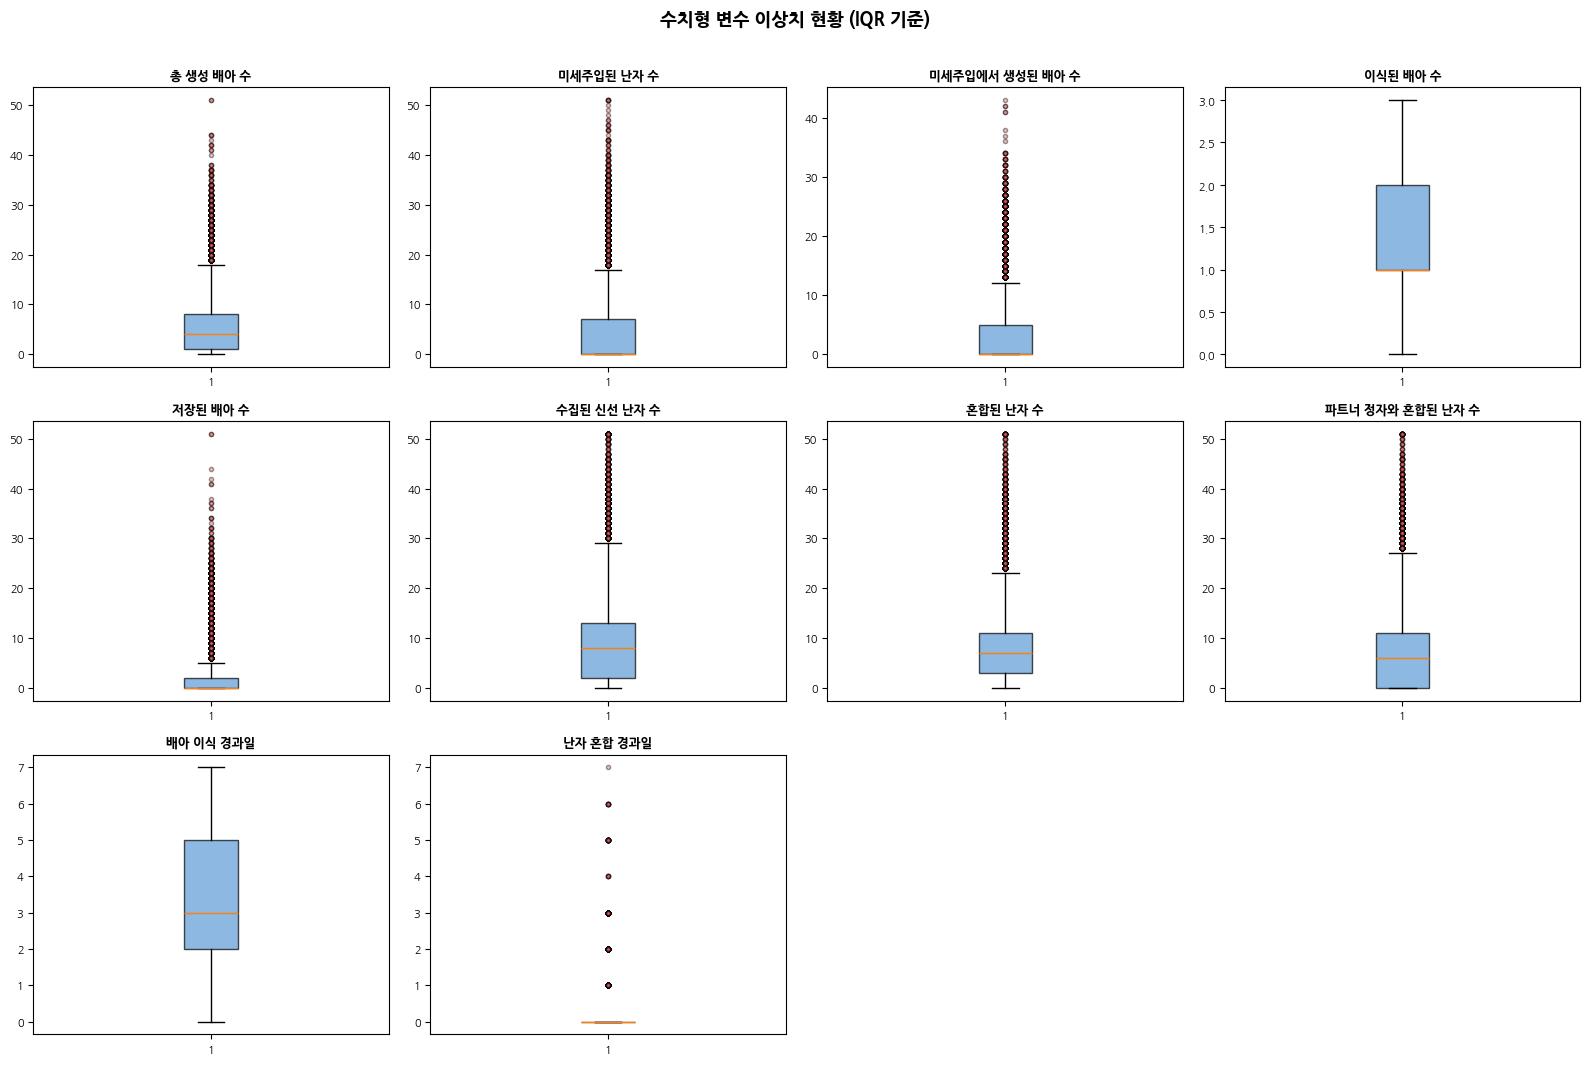

,컬럼명,최솟값,Q1,중앙값,Q3,최댓값,이상치 수,이상치율(%),하한,상한
0,총 생성 배아 수,0.0,1.0,4.0,8.0,51.0,3312,1.3,-9.5,18.5
1,미세주입된 난자 수,0.0,0.0,0.0,7.0,51.0,7511,3.0,-10.5,17.5
2,미세주입에서 생성된 배아 수,0.0,0.0,0.0,5.0,43.0,8524,3.4,-7.5,12.5
3,이식된 배아 수,0.0,1.0,1.0,2.0,3.0,0,0.0,-0.5,3.5
4,저장된 배아 수,0.0,0.0,0.0,2.0,51.0,14218,5.7,-3.0,5.0
5,수집된 신선 난자 수,0.0,2.0,8.0,13.0,51.0,2733,1.1,-14.5,29.5
6,혼합된 난자 수,0.0,3.0,7.0,11.0,51.0,5314,2.1,-9.0,23.0
7,파트너 정자와 혼합된 난자 수,0.0,0.0,6.0,11.0,51.0,2035,0.8,-16.5,27.5
8,배아 이식 경과일,0.0,2.0,3.0,5.0,7.0,0,0.0,-2.5,9.5
9,난자 혼합 경과일,0.0,0.0,0.0,0.0,7.0,696,0.3,0.0,0.0


In [20]:
def check_outliers(df, cols, title="이상치 현황 (IQR 기준)"):
    records = []
    for col in cols:
        if col not in df.columns:
            continue
        d = df[col].dropna()
        Q1, Q3 = d.quantile(0.25), d.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        out_cnt = ((d < lower) | (d > upper)).sum()
        records.append({
            "컬럼명"    : col,
            "최솟값"    : d.min(),  "Q1": Q1, "중앙값": d.median(),
            "Q3"        : Q3,       "최댓값": d.max(),
            "이상치 수" : out_cnt,
            "이상치율(%)": round(out_cnt / len(d) * 100, 1),
            "하한"      : round(lower, 1), "상한": round(upper, 1),
        })

    summary = pd.DataFrame(records)
    print(f"\n{'='*72}\n  {title}\n{'='*72}")
    print(summary.set_index("컬럼명").to_string())

    n_cols = 4
    n_rows = (len(cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
    axes = axes.flatten()
    valid_cols = [c for c in cols if c in df.columns]
    for i, col in enumerate(valid_cols):
        data = df[col].dropna()
        bp = axes[i].boxplot(data, vert=True, patch_artist=True,
                             flierprops=dict(marker="o", markersize=3,
                                             markerfacecolor="#E05C5C", alpha=0.4))
        bp["boxes"][0].set_facecolor("#5B9BD5")
        bp["boxes"][0].set_alpha(0.7)
        axes[i].set_title(col, fontsize=9, fontweight="bold")
        axes[i].tick_params(labelsize=8)
    for j in range(len(valid_cols), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    return summary


NUM_COLS = [
    "총 생성 배아 수", "미세주입된 난자 수", "미세주입에서 생성된 배아 수",
    "이식된 배아 수", "저장된 배아 수", "수집된 신선 난자 수",
    "혼합된 난자 수", "파트너 정자와 혼합된 난자 수",
    "배아 이식 경과일", "난자 혼합 경과일",
]
check_outliers(
    train.drop(columns=[ID_COL, TARGET], errors="ignore"),
    NUM_COLS, "수치형 변수 이상치 현황 (IQR 기준)"
)


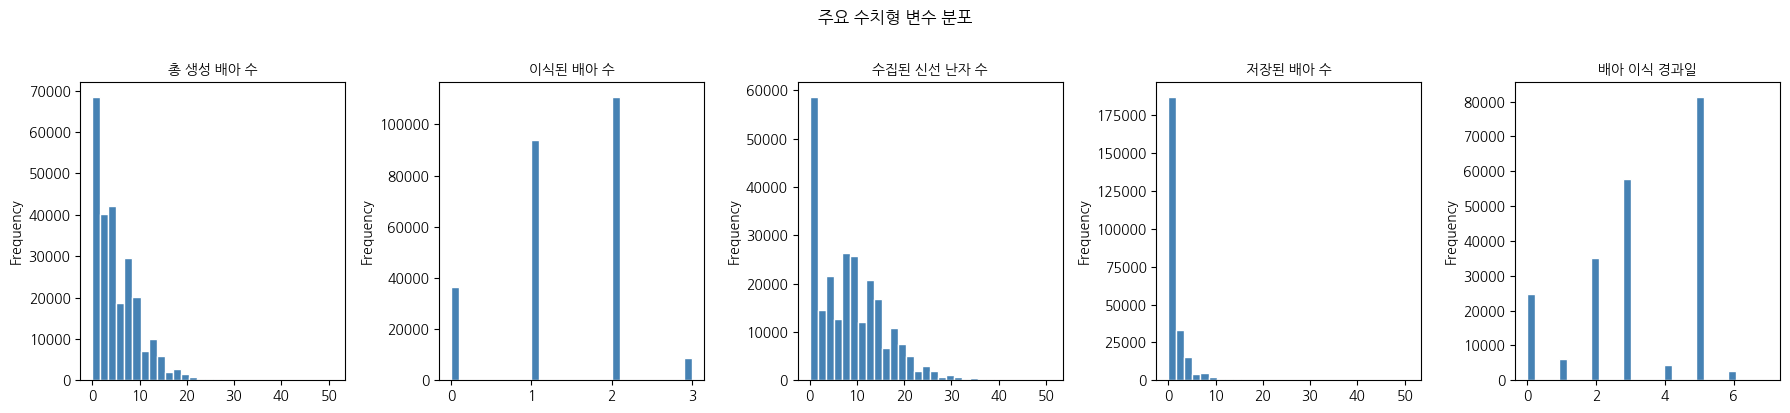

In [21]:
num_cols_view = ["총 생성 배아 수", "이식된 배아 수", "수집된 신선 난자 수",
                 "저장된 배아 수", "배아 이식 경과일"]
fig, axes = plt.subplots(1, len(num_cols_view), figsize=(18, 4))
for ax, col in zip(axes, num_cols_view):
    train[col].dropna().plot(kind="hist", bins=30, ax=ax,
                             color="steelblue", edgecolor="white")
    ax.set_title(col, fontsize=10)
plt.suptitle("주요 수치형 변수 분포", y=1.02)
plt.tight_layout()
plt.show()

In [22]:
AGE_MAP = {
    "만18-34세": 0, "만35-37세": 1, "만38-39세": 2,
    "만40-42세": 3, "만43-44세": 4, "만45-50세": 5,
    "알 수 없음": -1,
}
COUNT_MAP = {"0회": 0, "1회": 1, "2회": 2, "3회": 3, "4회": 4, "5회": 5, "6회 이상": 6}
DONOR_AGE_MAP = {
    "만20세 이하": 0, "만21-25세": 1, "만26-30세": 2,
    "만31-35세": 3,  "만36-40세": 4, "만41-45세": 5,
    "알 수 없음": -1,
}
COUNT_COLS = [
    "총 시술 횟수", "클리닉 내 총 시술 횟수",
    "IVF 시술 횟수", "DI 시술 횟수",
    "총 임신 횟수", "IVF 임신 횟수", "DI 임신 횟수",
    "총 출산 횟수", "IVF 출산 횟수", "DI 출산 횟수",
]

In [23]:
DROP_COLS = [
    "착상 전 유전 검사 사용 여부",   # 98.94% 결측, 비결측값 모두 1.0
    "PGD 시술 여부",                 # 99.15% 결측
    "PGS 시술 여부",                 # 99.25% 결측
    "불임 원인 - 여성 요인",          # zero variance
    "난자 채취 경과일",               # zero variance
    "난자 해동 경과일",               # 99.44% 결측
]

In [24]:
REASON_CATEGORIES = ["현재 시술용", "배아 저장용", "난자 저장용", "기증용", "연구용"]
PROCEDURE_TYPES   = ["IVF", "ICSI", "IUI", "ICI", "GIFT", "FER",
                     "BLASTOCYST", "AH", "Generic DI", "IVI"]

def expand_reason(df):
    col = "배아 생성 주요 이유"
    for cat in REASON_CATEGORIES:
        df[f"이유_{cat}"] = df[col].fillna("").str.contains(cat).astype(int)
    return df

def expand_procedure(df):
    col = "특정 시술 유형"
    filled = df[col].fillna("Unknown")
    for pt in PROCEDURE_TYPES:
        df[f"시술_{pt}"] = (
            filled.str.upper().str.replace(" ", "", regex=False)
            .str.contains(pt.upper()).astype(int)
        )
    return df

In [25]:
def preprocess(df: pd.DataFrame, fit_label_encoders=None) -> tuple:
    df = df.copy()

    # 컬럼 제거
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

    # 임신 시도 연수 (96% 결측) → 결측 지시 변수 + -1 대체
    col_years = "임신 시도 또는 마지막 임신 경과 연수"
    if col_years in df.columns:
        df["임신_시도_연수_결측"] = df[col_years].isnull().astype(int)
        df[col_years] = df[col_years].fillna(-1)

    # 배아 해동 경과일 (84% 결측) → 결측 지시 변수 + 0 대체
    col_thaw = "배아 해동 경과일"
    if col_thaw in df.columns:
        df["배아_해동_결측"] = df[col_thaw].isnull().astype(int)
        df[col_thaw] = df[col_thaw].fillna(0)

    # DI 시술행 IVF 전용 컬럼 → 0 대체
    FILL_ZERO_COLS = [
        "단일 배아 이식 여부", "착상 전 유전 진단 사용 여부", "배아 생성 주요 이유",
        "총 생성 배아 수", "미세주입된 난자 수", "미세주입에서 생성된 배아 수",
        "이식된 배아 수", "미세주입 배아 이식 수", "저장된 배아 수",
        "미세주입 후 저장된 배아 수", "해동된 배아 수", "해동 난자 수",
        "수집된 신선 난자 수", "저장된 신선 난자 수", "혼합된 난자 수",
        "파트너 정자와 혼합된 난자 수", "기증자 정자와 혼합된 난자 수",
        "동결 배아 사용 여부", "신선 배아 사용 여부", "기증 배아 사용 여부", "대리모 여부",
    ]
    for col in FILL_ZERO_COLS:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # 경과일 컬럼 중앙값 대체
    for col in ["난자 혼합 경과일", "배아 이식 경과일"]:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # 순서형 인코딩: 나이
    if "시술 당시 나이" in df.columns:
        df["시술 당시 나이"] = df["시술 당시 나이"].map(AGE_MAP).fillna(-1).astype(int)

    # 순서형 인코딩: 횟수 컬럼
    for col in COUNT_COLS:
        if col in df.columns:
            df[col] = df[col].map(COUNT_MAP).fillna(-1).astype(int)

    # 순서형 인코딩: 기증자 나이
    for col in ["난자 기증자 나이", "정자 기증자 나이"]:
        if col in df.columns:
            df[col] = df[col].map(DONOR_AGE_MAP).fillna(-1).astype(int)

    # 시술 유형 이진화 (IVF=1, DI=0)
    if "시술 유형" in df.columns:
        df["시술 유형"] = (df["시술 유형"] == "IVF").astype(int)

    # 배란 유도 유형 인코딩
    induction_map = {
        "알 수 없음": 0, "기록되지 않은 시행": 1,
        "생식선 자극 호르몬": 2, "세트로타이드 (억제제)": 3,
    }
    if "배란 유도 유형" in df.columns:
        df["배란 유도 유형"] = df["배란 유도 유형"].map(induction_map).fillna(0).astype(int)

    # 난자/정자 출처 인코딩
    egg_map   = {"본인 제공": 0, "기증 제공": 1, "알 수 없음": -1}
    sperm_map = {"배우자 제공": 0, "기증 제공": 1, "배우자 및 기증 제공": 2, "미할당": -1}
    if "난자 출처" in df.columns:
        df["난자 출처"] = df["난자 출처"].map(egg_map).fillna(-1).astype(int)
    if "정자 출처" in df.columns:
        df["정자 출처"] = df["정자 출처"].map(sperm_map).fillna(-1).astype(int)

    # 시술 시기 코드 레이블 인코딩
    code_map = {v: i for i, v in enumerate(
        ["TRCMWS", "TRDQAZ", "TRJXFG", "TRVNRY", "TRXQMD", "TRYBLT", "TRZKPL"]
    )}
    if "시술 시기 코드" in df.columns:
        df["시술 시기 코드"] = df["시술 시기 코드"].map(code_map).fillna(-1).astype(int)

    # 레이블 인코딩: 명목형 범주  ← project_1.ipynb
    LABEL_ENC_COLS = ["배아 생성 주요 이유", "특정 시술 유형"]
    label_encoders = fit_label_encoders or {}
    for col in LABEL_ENC_COLS:
        if col not in df.columns:
            continue
        if col not in label_encoders:
            le = LabelEncoder()
            le.fit(df[col].fillna("Unknown").astype(str))
            label_encoders[col] = le
        df[col] = label_encoders[col].transform(df[col].fillna("Unknown").astype(str))

    # 이진 컬럼 결측 → 0
    binary_cols = [
        "배란 자극 여부", "단일 배아 이식 여부", "착상 전 유전 진단 사용 여부",
        "남성 주 불임 원인", "남성 부 불임 원인",
        "여성 주 불임 원인", "여성 부 불임 원인",
        "부부 주 불임 원인", "부부 부 불임 원인", "불명확 불임 원인",
        "불임 원인 - 난관 질환", "불임 원인 - 남성 요인", "불임 원인 - 배란 장애",
        "불임 원인 - 자궁경부 문제", "불임 원인 - 자궁내막증",
        "불임 원인 - 정자 농도", "불임 원인 - 정자 면역학적 요인",
        "불임 원인 - 정자 운동성", "불임 원인 - 정자 형태",
        "동결 배아 사용 여부", "신선 배아 사용 여부",
        "기증 배아 사용 여부", "대리모 여부",
    ]
    for c in binary_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)

    # 연속형 수치 결측 → 중앙값
    cont_cols = [
        "총 생성 배아 수", "미세주입된 난자 수", "미세주입에서 생성된 배아 수",
        "이식된 배아 수", "미세주입 배아 이식 수",
        "저장된 배아 수", "미세주입 후 저장된 배아 수",
        "해동된 배아 수", "해동 난자 수",
        "수집된 신선 난자 수", "저장된 신선 난자 수",
        "혼합된 난자 수", "파트너 정자와 혼합된 난자 수", "기증자 정자와 혼합된 난자 수",
        "난자 혼합 경과일", "배아 이식 경과일", "배아 해동 경과일",
    ]
    for c in cont_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
            df[c] = df[c].fillna(df[c].median() if df[c].notna().any() else -1)

    return df, label_encoders


# 멀티레이블 분리는 전처리 전에 적용
def preprocess_full(df, fit_label_encoders=None):
    df = expand_reason(df.copy())
    df = expand_procedure(df)
    df.drop(columns=["배아 생성 주요 이유", "특정 시술 유형"],
            inplace=True, errors="ignore")
    df, le = preprocess(df, fit_label_encoders)
    return df, le


X_raw = train.drop(columns=[ID_COL, TARGET], errors="ignore")
y     = train[TARGET]
X_test_raw = test.drop(columns=[ID_COL], errors="ignore")

X_pp, label_encoders = preprocess_full(X_raw)
X_test_pp, _         = preprocess_full(X_test_raw, fit_label_encoders=label_encoders)

print(f"\n  전처리 후 Train shape: {X_pp.shape}")
print(f"  전처리 후 Test  shape: {X_test_pp.shape}")
print(f"  잔여 결측치 (Train): {X_pp.isnull().sum().sum()}")


  전처리 후 Train shape: (256351, 76)
  전처리 후 Test  shape: (90067, 76)
  잔여 결측치 (Train): 0


이변량 분석


In [26]:
AGE_ORDER   = ["만18-34세","만35-37세","만38-39세","만40-42세","만43-44세","만45-50세","알 수 없음"]
COUNT_ORDER = ["0회","1회","2회","3회","4회","5회","6회 이상"]

파생변수

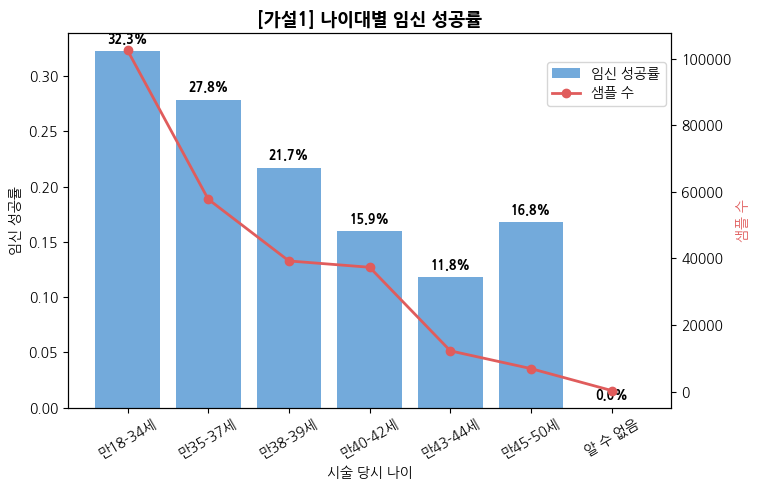

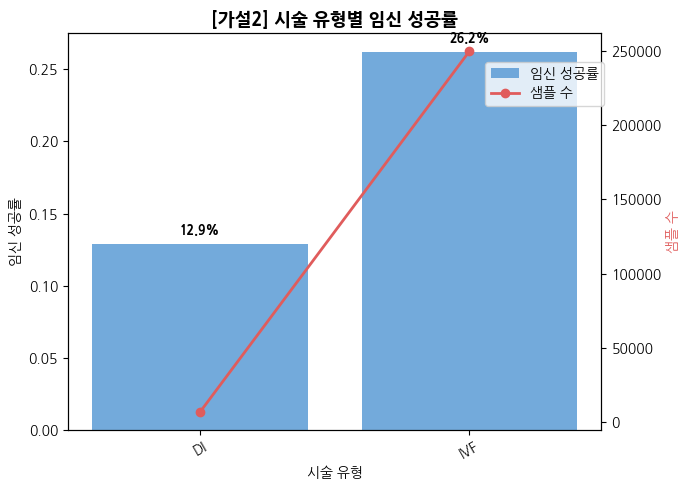

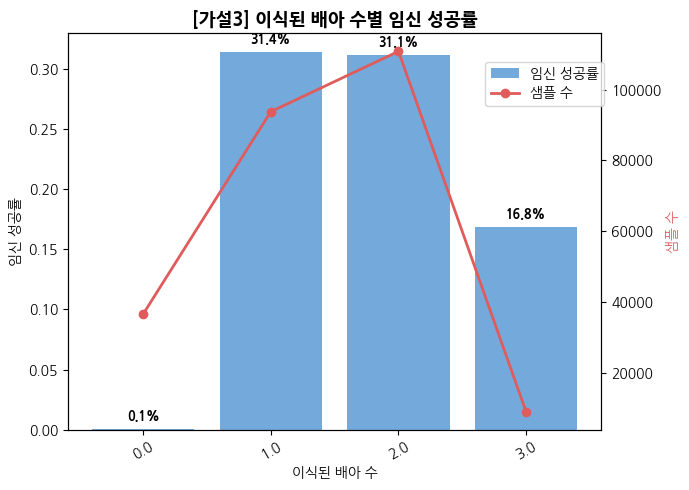

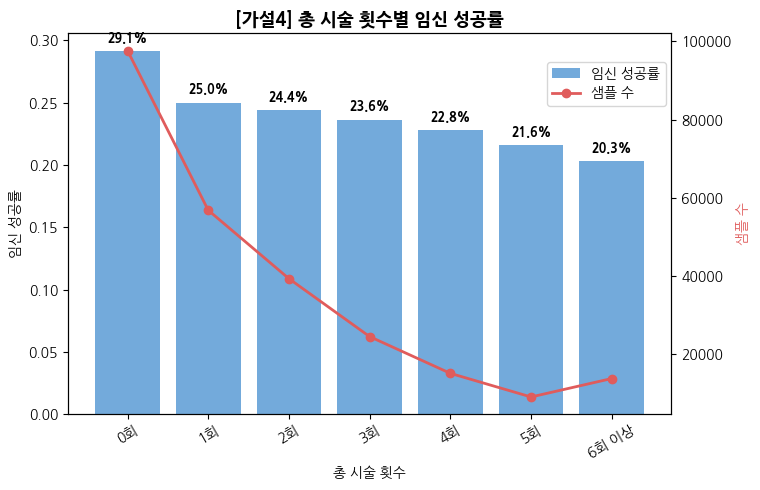

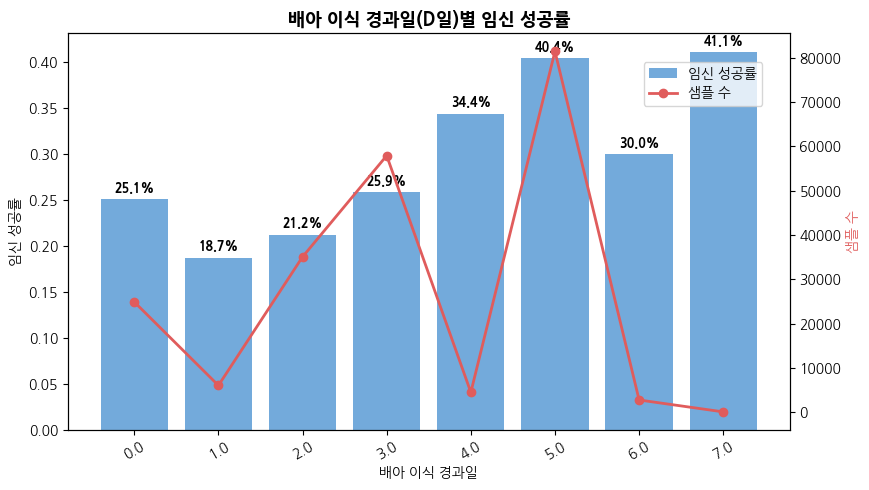

In [27]:
def plot_cat_vs_target(df, col, target, title=None, order=None):
    if col not in df.columns:
        print(f"  컬럼 없음: {col}")
        return
    grp = df.groupby(col)[target].agg(success_rate="mean", count="count").reset_index()
    if order:
        grp[col] = pd.Categorical(grp[col], categories=order, ordered=True)
        grp = grp.sort_values(col)

    fig, ax1 = plt.subplots(figsize=(max(7, len(grp) * 1.1), 5))
    ax2 = ax1.twinx()
    bars = ax1.bar(grp[col].astype(str), grp["success_rate"], color="#5B9BD5", alpha=0.85, label="임신 성공률")
    ax2.plot(grp[col].astype(str), grp["count"], color="#E05C5C", marker="o", linewidth=2, label="샘플 수")
    for bar, row in zip(bars, grp.itertuples()):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f"{row.success_rate:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax1.set_ylabel("임신 성공률"); ax2.set_ylabel("샘플 수", color="#E05C5C")
    ax1.set_xlabel(col); ax1.tick_params(axis="x", rotation=30)
    plt.title(title or f"{col}별 임신 성공률", fontsize=13, fontweight="bold")
    fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
    plt.tight_layout(); plt.show()


# 가설 1: 나이대별 성공률
plot_cat_vs_target(df, "시술 당시 나이", TARGET, "[가설1] 나이대별 임신 성공률", AGE_ORDER)

# 가설 2: 시술 유형별 성공률
plot_cat_vs_target(df, "시술 유형", TARGET, "[가설2] 시술 유형별 임신 성공률")

# 가설 3: 이식 배아 수별 성공률
plot_cat_vs_target(df, "이식된 배아 수", TARGET, "[가설3] 이식된 배아 수별 임신 성공률")

# 가설 4: 총 시술 횟수별 성공률
plot_cat_vs_target(df, "총 시술 횟수", TARGET, "[가설4] 총 시술 횟수별 임신 성공률", COUNT_ORDER)

# 배아 이식 경과일(D일)별 성공률
plot_cat_vs_target(df, "배아 이식 경과일", TARGET, "배아 이식 경과일(D일)별 임신 성공률")

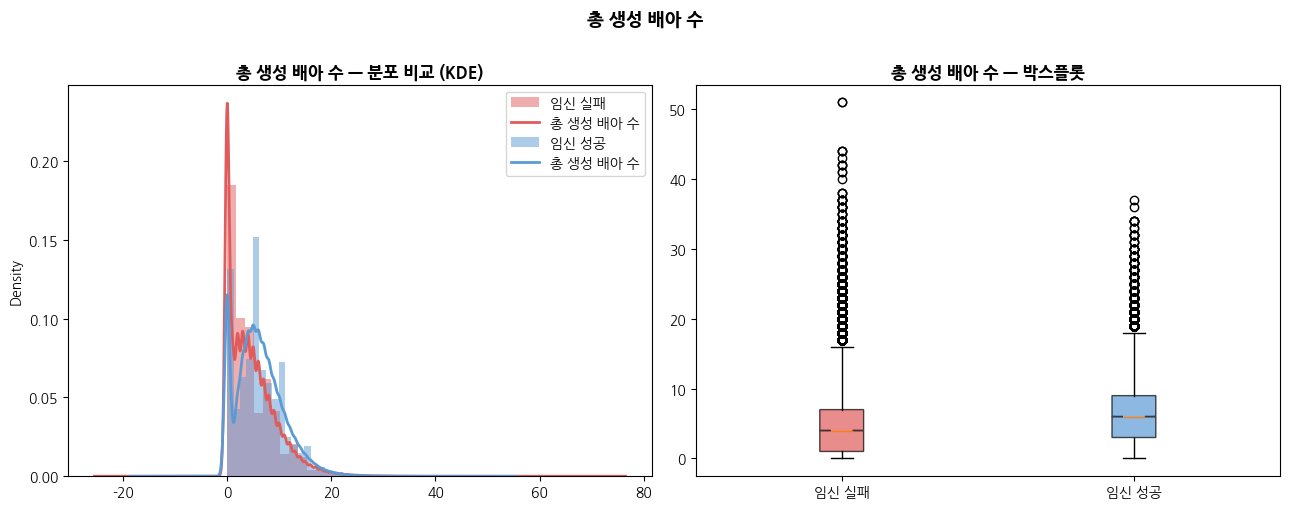

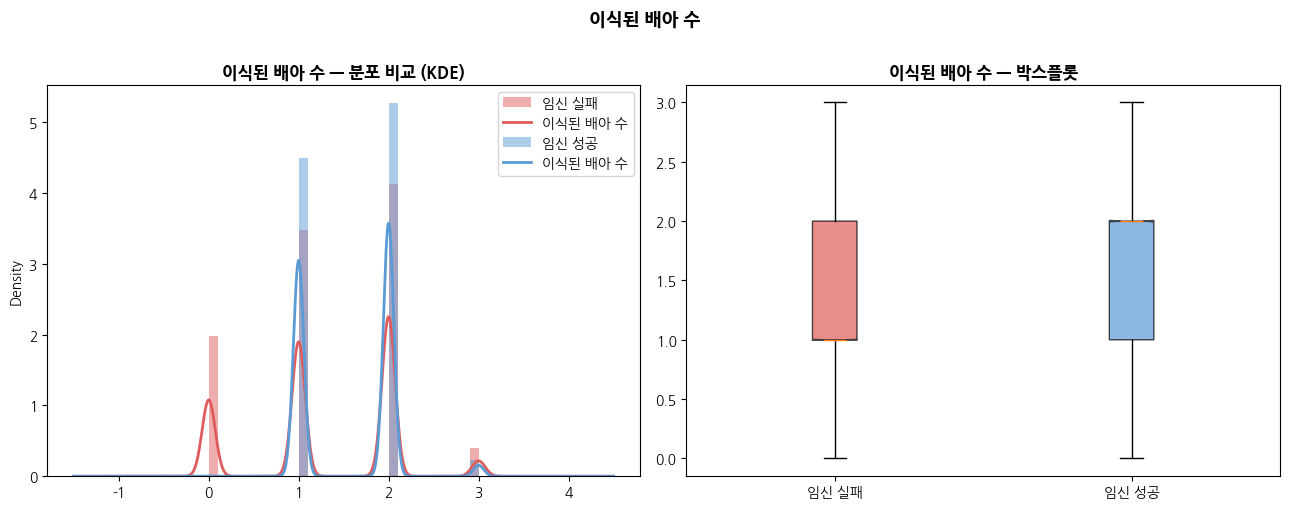

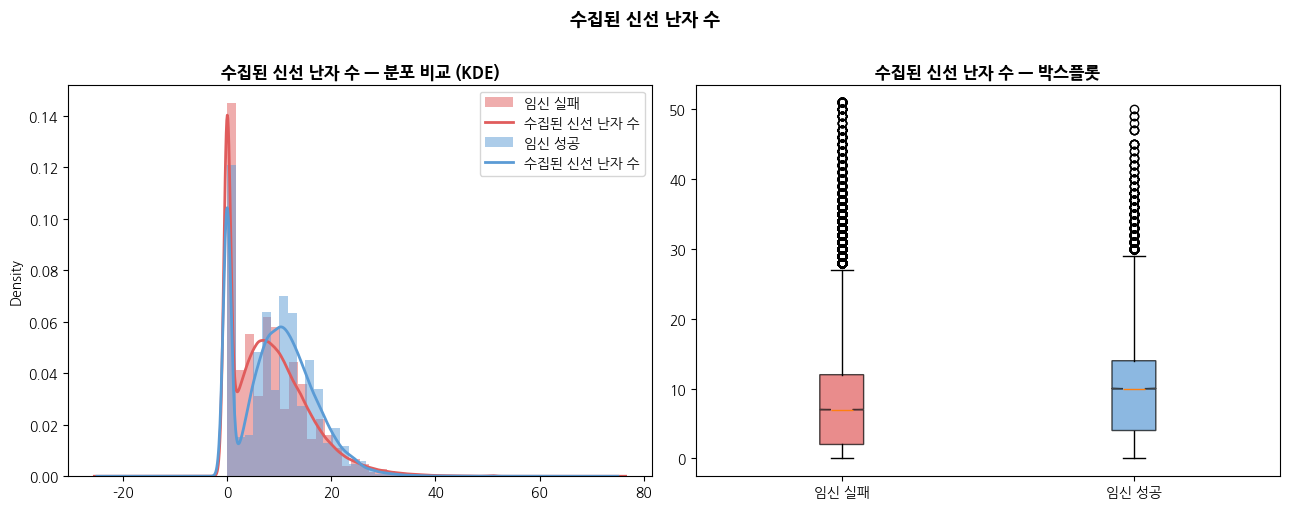

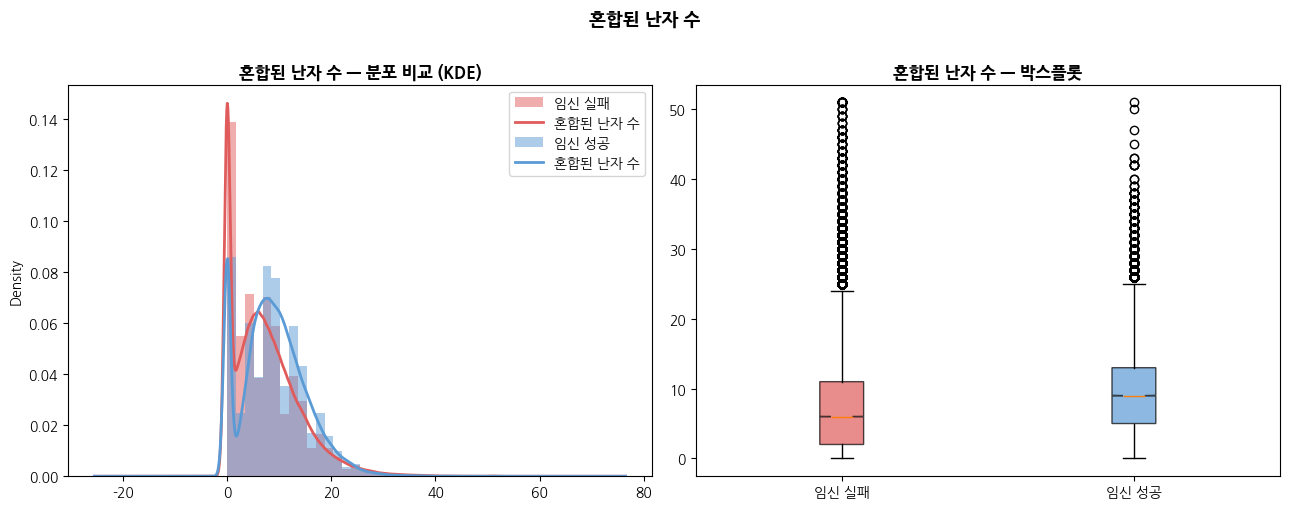

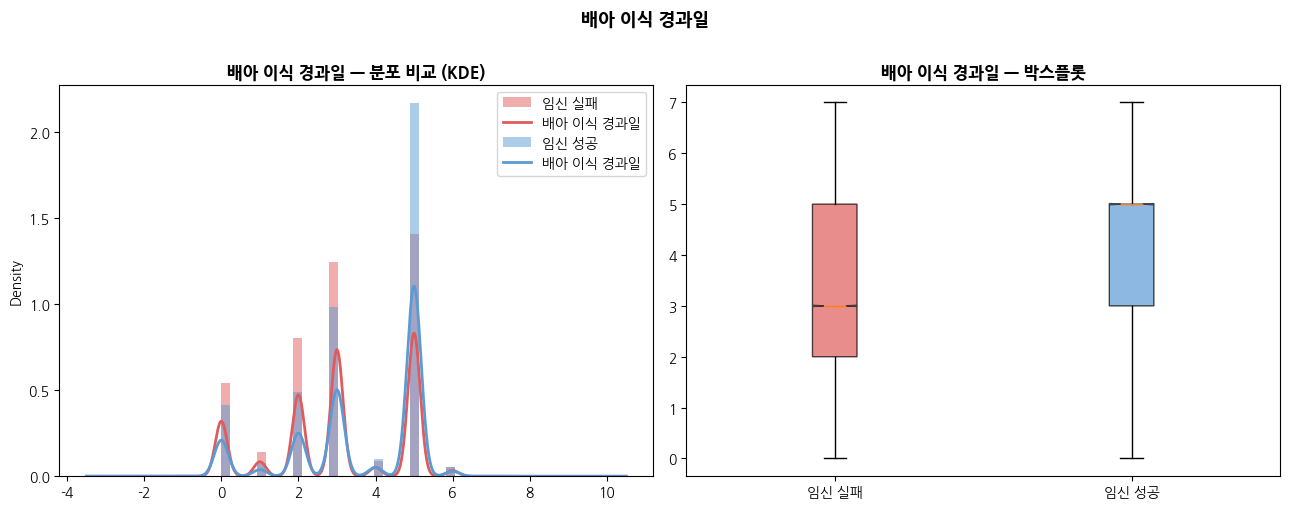

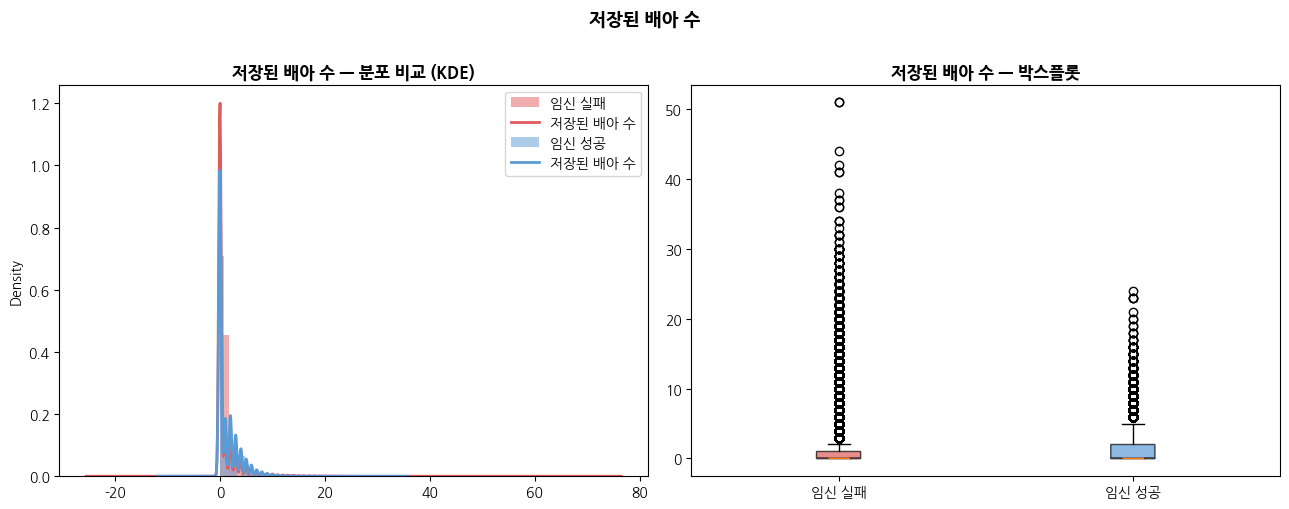

In [28]:
def plot_num_vs_target(df, col, target, title=None):
    if col not in df.columns:
        return
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for val, label, color in [(0, "임신 실패", "#E05C5C"), (1, "임신 성공", "#5B9BD5")]:
        subset = df.loc[df[target] == val, col].dropna()
        axes[0].hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
        subset.plot.kde(ax=axes[0], color=color, linewidth=2)
    axes[0].set_title(f"{col} — 분포 비교 (KDE)", fontweight="bold")
    axes[0].legend()

    bp_data = [df.loc[df[target] == 0, col].dropna(), df.loc[df[target] == 1, col].dropna()]
    bp = axes[1].boxplot(bp_data, labels=["임신 실패", "임신 성공"], patch_artist=True, notch=True)
    for patch, color in zip(bp["boxes"], ["#E05C5C", "#5B9BD5"]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[1].set_title(f"{col} — 박스플롯", fontweight="bold")
    plt.suptitle(title or col, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout(); plt.show()


for col in ["총 생성 배아 수", "이식된 배아 수", "수집된 신선 난자 수",
            "혼합된 난자 수", "배아 이식 경과일", "저장된 배아 수"]:
    plot_num_vs_target(df, col, TARGET)


5. 상관관계 분석


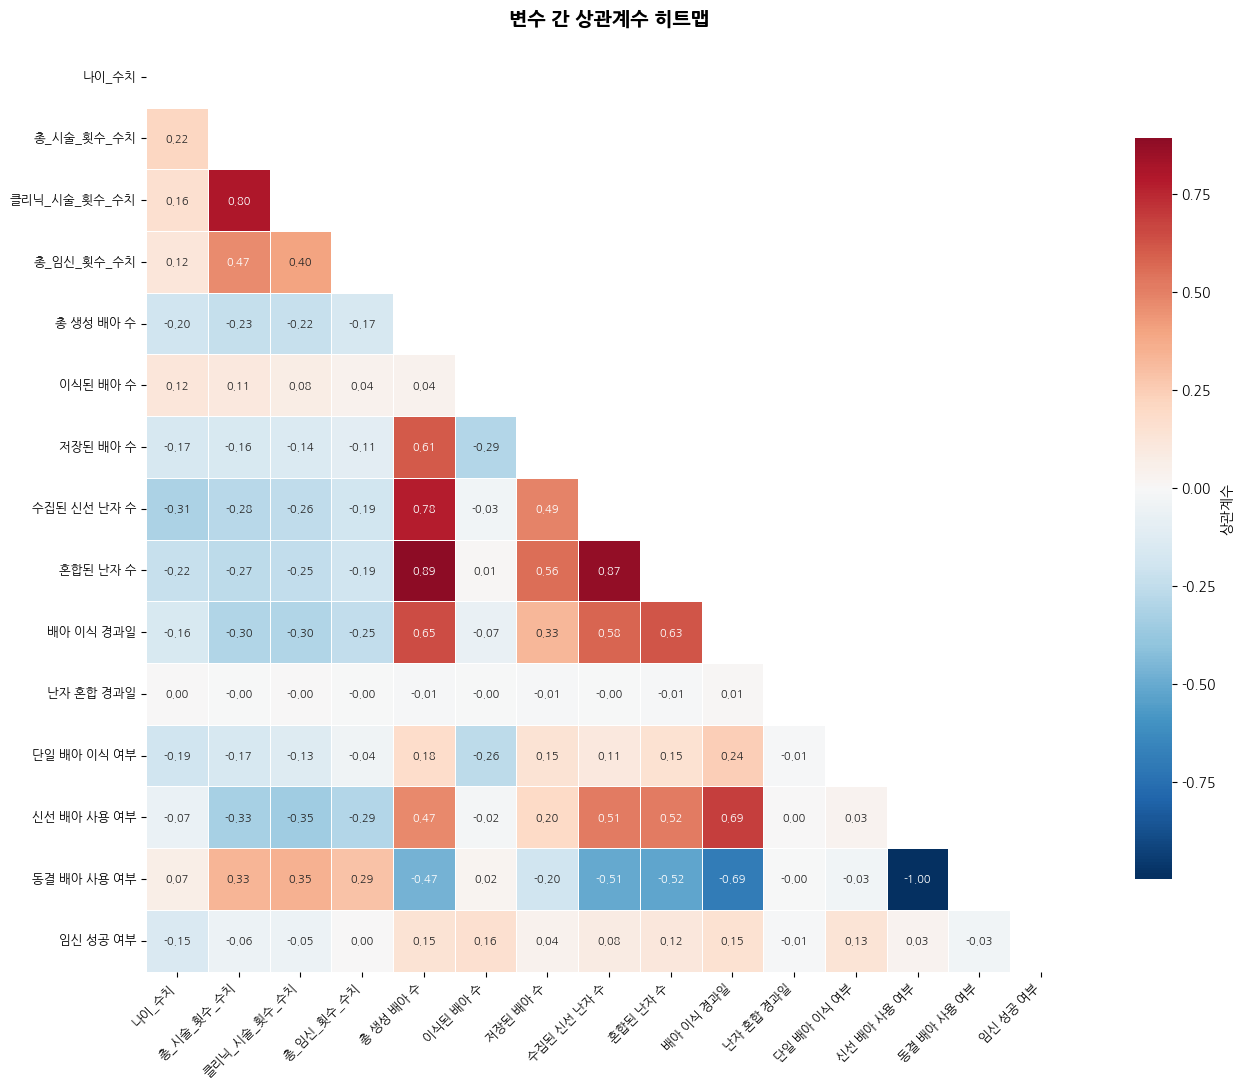

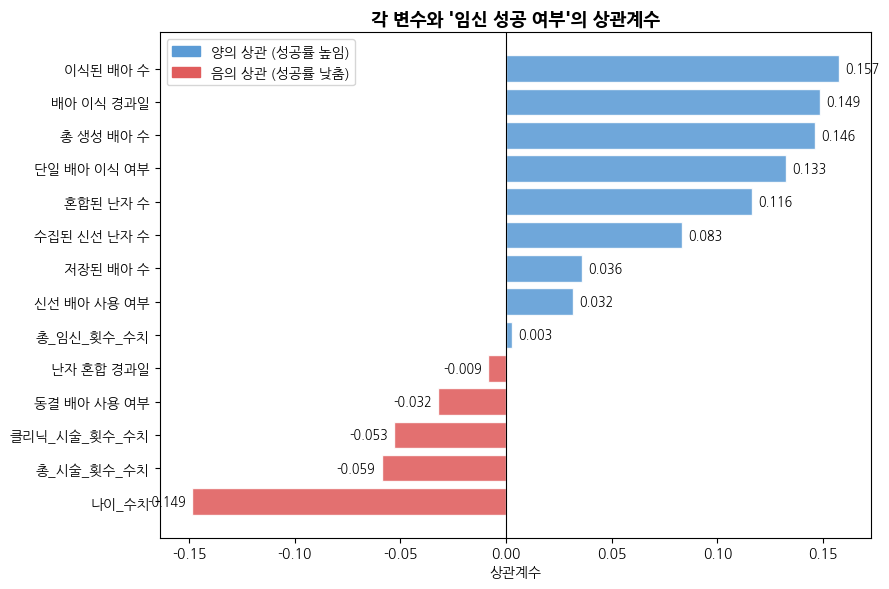


  타겟과 상관계수 TOP 10:
이식된 배아 수        0.1575
나이_수치           0.1487
배아 이식 경과일       0.1486
총 생성 배아 수       0.1461
단일 배아 이식 여부     0.1326
혼합된 난자 수        0.1161
수집된 신선 난자 수     0.0830
총_시술_횟수_수치      0.0589
클리닉_시술_횟수_수치    0.0528
저장된 배아 수        0.0360


In [29]:
print("\n" + "=" * 60)
print("5. 상관관계 분석")
print("=" * 60)

df_corr = df.copy()

# 범주형을 수치로 변환 (상관분석용)
df_corr["나이_수치"]             = df_corr["시술 당시 나이"].map(AGE_MAP)
df_corr["총_시술_횟수_수치"]     = df_corr["총 시술 횟수"].map(COUNT_MAP)
df_corr["클리닉_시술_횟수_수치"] = df_corr["클리닉 내 총 시술 횟수"].map(COUNT_MAP)
df_corr["총_임신_횟수_수치"]     = df_corr["총 임신 횟수"].map(COUNT_MAP)

CORR_COLS = [c for c in [
    "나이_수치", "총_시술_횟수_수치", "클리닉_시술_횟수_수치", "총_임신_횟수_수치",
    "총 생성 배아 수", "이식된 배아 수", "저장된 배아 수",
    "수집된 신선 난자 수", "혼합된 난자 수",
    "배아 이식 경과일", "난자 혼합 경과일",
    "단일 배아 이식 여부", "신선 배아 사용 여부", "동결 배아 사용 여부",
    TARGET,
] if c in df_corr.columns]

corr_matrix = df_corr[CORR_COLS].corr()

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, square=True,
    linewidths=0.4, cbar_kws={"label": "상관계수", "shrink": 0.8},
    annot_kws={"size": 8},
)
plt.title("변수 간 상관계수 히트맵", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout(); plt.show()

# 타겟과의 상관계수 막대그래프
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values()
colors_corr = ["#E05C5C" if v < 0 else "#5B9BD5" for v in target_corr.values]
plt.figure(figsize=(9, max(6, len(target_corr) * 0.42)))
bars = plt.barh(target_corr.index, target_corr.values, color=colors_corr, alpha=0.88, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, target_corr.values):
    plt.text(val + (0.003 if val >= 0 else -0.003),
             bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center",
             ha="left" if val >= 0 else "right", fontsize=9)
plt.xlabel("상관계수")
plt.title(f"각 변수와 '{TARGET}'의 상관계수", fontsize=13, fontweight="bold")
legend_patches = [
    mpatches.Patch(color="#5B9BD5", label="양의 상관 (성공률 높임)"),
    mpatches.Patch(color="#E05C5C", label="음의 상관 (성공률 낮춤)"),
]
plt.legend(handles=legend_patches)
plt.tight_layout(); plt.show()

print("\n  타겟과 상관계수 TOP 10:")
print(target_corr.abs().sort_values(ascending=False).head(10).round(4).to_string())

피처 엔지니어링

In [30]:
def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 불임 원인 개수 합산
    cause_cols = [c for c in df.columns if "불임 원인 -" in c]
    df["불임_원인_합계"] = df[cause_cols].sum(axis=1)

    # 주요 불임 원인 합계
    primary_cols = [c for c in ["남성 주 불임 원인", "여성 주 불임 원인", "부부 주 불임 원인"]
                    if c in df.columns]
    df["주요_불임_원인_합계"] = df[primary_cols].sum(axis=1)

    # 이식 효율: 이식 배아 / 생성 배아
    df["이식_효율"] = np.where(
        df["총 생성 배아 수"] > 0,
        df["이식된 배아 수"] / df["총 생성 배아 수"], 0
    )

    # ICSI 비율
    if "미세주입에서 생성된 배아 수" in df.columns:
        df["ICSI_비율"] = np.where(
            df["총 생성 배아 수"] > 0,
            df["미세주입에서 생성된 배아 수"] / df["총 생성 배아 수"], 0
        )

    # 과거 임신 성공률
    if "총 임신 횟수" in df.columns and "총 시술 횟수" in df.columns:
        df["과거_임신_성공률"] = np.where(
            df["총 시술 횟수"] > 0,
            df["총 임신 횟수"] / (df["총 시술 횟수"] + 1), 0
        )

    # 배아 전략 플래그 (동결=1, 기증=2, 신선=0)
    for col in ["동결 배아 사용 여부", "신선 배아 사용 여부", "기증 배아 사용 여부"]:
        if col not in df.columns:
            df[col] = 0
    df["배아_전략"] = (
        df["동결 배아 사용 여부"] * 1
        + df["신선 배아 사용 여부"] * 0
        + df["기증 배아 사용 여부"] * 2
    )

    # 저장 비율
    df["저장_비율"] = np.where(
        df["총 생성 배아 수"] > 0,
        df["저장된 배아 수"] / df["총 생성 배아 수"], 0
    )

    # 기증 사용 플래그
    df["기증_사용"] = (
        (df.get("난자 출처", pd.Series(0, index=df.index)) == 1)
        | (df.get("정자 출처", pd.Series(0, index=df.index)) == 1)
    ).astype(int)

      # 동결배아 활용률: 실제 해동 사용 / 저장 총수
    #   → 높을수록 보관 배아를 적극 활용한 주기
    if "해동된 배아 수" in df.columns:
        df["동결배아_활용률"] = np.where(
            df["저장된 배아 수"] > 0,
            df["해동된 배아 수"] / df["저장된 배아 수"], 0
        )

    # ICSI 후 동결된 배아 비율: ICSI 저장 / 이식 배아
    #   → 미세주입 배아 중 실제 이식 외 저장된 비중
    if "미세주입 후 저장된 배아 수" in df.columns:
        df["ICSI동결_이식비율"] = np.where(
            df["이식된 배아 수"] > 0,
            df["미세주입 후 저장된 배아 수"] / df["이식된 배아 수"], 0
        )

    # 순수 동결 주기 플래그: 동결=1 & 신선=0
    #   → 신선 배아 없이 동결만 사용한 주기 (FER 주기)
    df["순수동결_주기"] = (
        (df["동결 배아 사용 여부"] == 1) & (df["신선 배아 사용 여부"] == 0)
    ).astype(int)

    # 동결 잉여율: (저장 - 해동) / 저장
    #   → 아직 남아있는 동결 배아 비율 (낮을수록 소진됨)
    if "해동된 배아 수" in df.columns:
        remaining = (df["저장된 배아 수"] - df["해동된 배아 수"]).clip(lower=0)
        df["동결배아_잉여율"] = np.where(
            df["저장된 배아 수"] > 0,
            remaining / df["저장된 배아 수"], 0
        )

    # 동결 배아 총량 지수: 저장 + 해동 (해동 포함 시)
    #   → 누적 동결 배아 규모를 반영
    if "해동된 배아 수" in df.columns:
        df["동결배아_총량"] = df["저장된 배아 수"] + df["해동된 배아 수"]
    # 전처리 후 "시술 당시 나이"는 순서형 정수 0~5 (-1=알 수 없음)
    # "수집된 신선 난자 수"는 연속형 수치

    if "수집된 신선 난자 수" in df.columns and "시술 당시 나이" in df.columns:
        age_num = df["시술 당시 나이"].replace(-1, np.nan)  # 알 수 없음 → NaN
        egg_cnt = df["수집된 신선 난자 수"]

        # 나이 × 난자 수 교호작용항
        #   → 나이 코드가 높고 난자도 많은 경우 큰 값 (고령 고수확)
        df["나이x난자수"] = (age_num * egg_cnt).fillna(0)

        # 나이 보정 난자 효율: 난자 수 / (나이 코드 + 1)
        #   → 같은 난자 수라도 나이가 낮을수록 효율이 높음을 표현
        df["나이보정_난자효율"] = (egg_cnt / (age_num.fillna(0) + 1))

        # 혼합 난자 대비 수정 효율: 총 배아 / 혼합 난자
        #   → 난자 수정 성공률 근사
        if "혼합된 난자 수" in df.columns:
            df["수정_효율"] = np.where(
                df["혼합된 난자 수"] > 0,
                df["총 생성 배아 수"] / df["혼합된 난자 수"], 0
            )

        # 고령 저반응 플래그: 나이 >= 3 (만40-42세+) AND 난자 수 < 중앙값
        #   → 고령임에도 채취 수가 낮은 불량 예후 케이스
        egg_median = egg_cnt.median()
        df["고령저반응"] = (
            (age_num >= 3) & (egg_cnt < egg_median)
        ).fillna(False).astype(int)

        # 젊고 고수확 플래그: 나이 <= 1 (만18-37세) AND 난자 수 >= 75th 백분위
        egg_q75 = egg_cnt.quantile(0.75)
        df["젊고고수확"] = (
            (age_num <= 1) & (egg_cnt >= egg_q75)
        ).fillna(False).astype(int)
      # 배아 손실 수: 생성 - 이식 - 저장 (폐기된 배아 추정)
    #   → 낮을수록 배아 관리 효율이 좋음
    df["배아_손실수"] = (
        df["총 생성 배아 수"]
        - df["이식된 배아 수"]
        - df["저장된 배아 수"]
    ).clip(lower=0)

    # 배아 총 활용률: (이식 + 저장) / 생성
    #   → 1에 가까울수록 생성 배아를 모두 활용
    df["배아_총활용률"] = np.where(
        df["총 생성 배아 수"] > 0,
        (df["이식된 배아 수"] + df["저장된 배아 수"]) / df["총 생성 배아 수"], 0
    ).clip(0, 1)

    # 배아 풍요도 구간: 0=없음, 1=적음(1-3), 2=보통(4-7), 3=많음(8+)
    embryo_max = max(df["총 생성 배아 수"].max() + 1, 9)
    df["배아_풍요도"] = pd.cut(
        df["총 생성 배아 수"],
        bins=[-1, 0, 3, 7, embryo_max],
        labels=[0, 1, 2, 3]
    ).astype(float).fillna(0).astype(int)

    # 다배아 이식 플래그: 이식 배아 >= 3 (다태 임신 위험 기준)
    df["다배아이식_플래그"] = (df["이식된 배아 수"] >= 3).astype(int)

    # 배아 품질 복합 지수: 이식 효율 × 배아 총 활용률
    #   → 두 효율 지표를 동시에 고려한 종합 배아 품질 점수 (0~1)
    df["배아품질_복합지수"] = df["이식_효율"] * df["배아_총활용률"]

    # ICSI 배아 우위 비율: ICSI 배아 / 총 배아
    #   → 미세주입 의존도. 높을수록 정자 문제 가능성
    if "미세주입에서 생성된 배아 수" in df.columns:
        df["ICSI배아_우위비율"] = np.where(
            df["총 생성 배아 수"] > 0,
            df["미세주입에서 생성된 배아 수"] / df["총 생성 배아 수"], 0
        )

    # 이식 집중도: 이식 배아 / (이식 + 저장)
    #   → 보관보다 즉시 이식에 집중한 정도
    denom_43 = df["이식된 배아 수"] + df["저장된 배아 수"]
    df["이식_집중도"] = np.where(denom_43 > 0, df["이식된 배아 수"] / denom_43, 0)

    if "시술 유형" in df.columns and "시술 당시 나이" in df.columns:
        age_num2 = df["시술 당시 나이"].replace(-1, 0)  # 알 수 없음 → 0

        # 나이 × 시술 유형 교호작용항
        #   → IVF 시술 + 나이가 높을수록 큰 값. IVF의 나이 의존성 포착
        df["나이x시술유형"] = age_num2 * df["시술 유형"]

        # 고령 IVF 플래그: 나이 >= 3 (만40+) AND IVF 시술
        #   → 고령에서 IVF를 선택한 고위험 케이스
        df["고령IVF"] = (
            (df["시술 당시 나이"] >= 3) & (df["시술 유형"] == 1)
        ).astype(int)

        # 젊은 DI 플래그: 나이 <= 1 (만18-37세) AND DI 시술
        #   → 상대적으로 단순 시술로도 기대치가 높은 케이스
        df["젊은DI"] = (
            (df["시술 당시 나이"] <= 1) & (df["시술 유형"] == 0)
        ).astype(int)

        # 나이 구간별 시술 유형 복합 코드: age_band * 10 + procedure_type
        #   → 나이-시술 조합을 단일 범주로 표현 (트리 모델에서 분기 포착)
        df["나이_시술_복합코드"] = df["시술 당시 나이"].clip(lower=0) * 10 + df["시술 유형"]

    if "총 시술 횟수" in df.columns and "시술 당시 나이" in df.columns:
        age_num3  = df["시술 당시 나이"].replace(-1, 0)
        trial_num = df["총 시술 횟수"].replace(-1, 0)

        # 나이 × 총 시술 횟수 교호작용항
        #   → 나이가 많고 시술 횟수가 많을수록 큰 값 (반복 실패 + 고령)
        df["나이x총시술횟수"] = age_num3 * trial_num

        # 클리닉 내 시술 횟수 교호작용 (동일 클리닉 내 축적 경험)
        if "클리닉 내 총 시술 횟수" in df.columns:
            clinic_num = df["클리닉 내 총 시술 횟수"].replace(-1, 0)
            df["나이x클리닉시술횟수"] = age_num3 * clinic_num

        # IVF 전용 시술 횟수 × 나이
        if "IVF 시술 횟수" in df.columns:
            ivf_num = df["IVF 시술 횟수"].replace(-1, 0)
            df["나이xIVF횟수"] = age_num3 * ivf_num

        # 고령 반복 시술 플래그: 나이 >= 3 AND 총 시술 횟수 >= 3
        #   → 고령 + 반복 실패 이력의 복합 고위험군
        df["고령반복시술"] = (
            (df["시술 당시 나이"] >= 3) & (trial_num >= 3)
        ).astype(int)

        # 시술 누적 부담 지수: 나이 × (총 시술 + IVF 시술) / 2
        #   → 나이와 시술 이력을 결합한 누적 부담 점수
        if "IVF 시술 횟수" in df.columns:
            ivf_num = df["IVF 시술 횟수"].replace(-1, 0)
            df["시술부담_지수"] = age_num3 * (trial_num + ivf_num) / 2

    print(f"  피처 수: {df.shape[1]}개")
    return df

X_train = feature_engineering(X_pp)
X_test  = feature_engineering(X_test_pp)

  피처 수: 110개
  피처 수: 110개


In [31]:
common_cols = [c for c in X_train.columns if c in X_test.columns]
X_train = X_train[common_cols]
X_test  = X_test[common_cols]

print(f"  최종 Train 피처: {X_train.shape[1]}개")
print(f"  최종 Test  피처: {X_test.shape[1]}개")

  최종 Train 피처: 110개
  최종 Test  피처: 110개


In [32]:
# ============================================================
# (기존 전처리/피처엔지니어링 코드 이후 여기서부터 실행)
# X_train, X_test, y 가 이미 정의되어 있다고 가정
# ============================================================

N_SPLITS = 5
SEED     = 42

# 타겟/피처 NaN 최종 검증
assert y.isna().sum() == 0,          f"y에 NaN 존재: {y.isna().sum()}개"
assert X_train.isna().sum().sum() == 0, "X_train에 NaN 존재!"
assert X_test.isna().sum().sum()  == 0, "X_test에 NaN 존재!"
print(f"✅ 검증 완료 | Train: {X_train.shape} | Test: {X_test.shape} | y 고유값: {sorted(y.unique())}")

✅ 검증 완료 | Train: (256351, 110) | Test: (90067, 110) | y 고유값: [np.int64(0), np.int64(1)]


In [33]:
# ============================================================
# 4. Optuna — XGBoost 튜닝 (30 trials)
# ============================================================
print("\n" + "=" * 60)
print("4. XGBoost Optuna 튜닝 (30 trials)")
print("=" * 60)

def objective_xgb(trial):
    params = {
        "objective":        "binary:logistic",
        "eval_metric":      "auc",
        "tree_method":      "hist",
        "seed":             SEED,
        "n_jobs":           -1,
        "verbosity":        0,
        "learning_rate":    trial.suggest_float("learning_rate",    0.01, 0.3,  log=True),
        "max_depth":        trial.suggest_int(  "max_depth",        3,    9),
        "min_child_weight": trial.suggest_int(  "min_child_weight", 1,    20),
        "subsample":        trial.suggest_float("subsample",        0.5,  1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5,  1.0),
        "gamma":            trial.suggest_float("gamma",            0.0,  5.0),
        "reg_alpha":        trial.suggest_float("reg_alpha",        1e-8, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda",       1e-8, 10.0, log=True),
    }
    cv_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = []
    for tr_idx, val_idx in cv_skf.split(X_train, y):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]
        dtrain = xgb.DMatrix(X_tr,  label=y_tr,  feature_names=list(X_train.columns))
        dval   = xgb.DMatrix(X_val, label=y_val, feature_names=list(X_train.columns))
        model  = xgb.train(params, dtrain, num_boost_round=1000,
                           evals=[(dval, "val")], early_stopping_rounds=50,
                           verbose_eval=False)
        scores.append(roc_auc_score(y_val, model.predict(dval)))
    return np.mean(scores)

study_xgb = optuna.create_study(direction="maximize",
                                 sampler=TPESampler(seed=SEED),
                                 study_name="xgb_tuning")
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

best_xgb_params = study_xgb.best_params.copy()
best_xgb_params.update({"objective": "binary:logistic", "eval_metric": "auc",
                         "tree_method": "hist", "seed": SEED,
                         "n_jobs": -1, "verbosity": 0})

print(f"\n  XGBoost 최적 파라미터:")
for k, v in study_xgb.best_params.items():
    print(f"    {k:<24}: {v}")
print(f"  Best CV AUC (3-fold): {study_xgb.best_value:.4f}")

print("\n  5-Fold 재학습 중...")
skf_xgb = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof_xgb, pred_xgb = np.zeros(len(X_train)), np.zeros(len(X_test))
fold_aucs_xgb = []

for fold, (tr_idx, val_idx) in enumerate(skf_xgb.split(X_train, y)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]
    dtrain = xgb.DMatrix(X_tr,  label=y_tr,  feature_names=list(X_train.columns))
    dval   = xgb.DMatrix(X_val, label=y_val, feature_names=list(X_train.columns))
    model  = xgb.train(best_xgb_params, dtrain, num_boost_round=2000,
                       evals=[(dval, "val")], early_stopping_rounds=100,
                       verbose_eval=False)
    oof_xgb[val_idx]  = model.predict(dval)
    pred_xgb         += model.predict(
        xgb.DMatrix(X_test, feature_names=list(X_train.columns))
    ) / N_SPLITS
    fold_aucs_xgb.append(roc_auc_score(y_val, oof_xgb[val_idx]))
    print(f"    Fold {fold+1}  AUC: {fold_aucs_xgb[-1]:.4f}")

xgb_oof_auc = roc_auc_score(y, oof_xgb)
print(f"  XGBoost OOF AUC: {xgb_oof_auc:.4f}")


4. XGBoost Optuna 튜닝 (30 trials)


  0%|          | 0/30 [00:00<?, ?it/s]


  XGBoost 최적 파라미터:
    learning_rate           : 0.01923706733849965
    max_depth               : 5
    min_child_weight        : 6
    subsample               : 0.5443803016454466
    colsample_bytree        : 0.5232246979025311
    gamma                   : 4.082142214651832
    reg_alpha               : 0.00034748005607724425
    reg_lambda              : 1.0705152367087479e-08
  Best CV AUC (3-fold): 0.7393

  5-Fold 재학습 중...
    Fold 1  AUC: 0.7373
    Fold 2  AUC: 0.7428
    Fold 3  AUC: 0.7398
    Fold 4  AUC: 0.7377
    Fold 5  AUC: 0.7405
  XGBoost OOF AUC: 0.7396


In [34]:
# ============================================================
# 5. Optuna — CatBoost 튜닝 (30 trials)
# ============================================================
print("\n" + "=" * 60)
print("5. CatBoost Optuna 튜닝 (30 trials)")
print("=" * 60)

def objective_cat(trial):
    params = {
        "eval_metric": "AUC", "early_stopping_rounds": 50,
        "random_seed": SEED, "verbose": 0, "task_type": "CPU",
        "iterations":        trial.suggest_int(  "iterations",        300,  1500),
        "learning_rate":     trial.suggest_float("learning_rate",     0.01, 0.3,  log=True),
        "depth":             trial.suggest_int(  "depth",             4,    10),
        "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg",       1.0,  10.0),
        "bootstrap_type":    trial.suggest_categorical("bootstrap_type",
                                                        ["Bayesian", "Bernoulli", "MVS"]),
        "min_data_in_leaf":  trial.suggest_int(  "min_data_in_leaf",  1,    50),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5,  1.0),
    }
    if params["bootstrap_type"] == "Bernoulli":
        params["subsample"] = trial.suggest_float("subsample", 0.5, 1.0)
    elif params["bootstrap_type"] == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0.0, 10.0)

    cv_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = []
    for tr_idx, val_idx in cv_skf.split(X_train, y):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]
        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
        scores.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
    return np.mean(scores)

study_cat = optuna.create_study(direction="maximize",
                                 sampler=TPESampler(seed=SEED),
                                 study_name="cat_tuning")
study_cat.optimize(objective_cat, n_trials=30, show_progress_bar=True)

best_cat_params = study_cat.best_params.copy()
best_cat_params.update({"eval_metric": "AUC", "early_stopping_rounds": 100,
                         "random_seed": SEED, "verbose": 0, "task_type": "CPU"})

print(f"\n  CatBoost 최적 파라미터:")
for k, v in study_cat.best_params.items():
    print(f"    {k:<24}: {v}")
print(f"  Best CV AUC (3-fold): {study_cat.best_value:.4f}")

print("\n  5-Fold 재학습 중...")
skf_cat = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED + 1)
oof_cat, pred_cat = np.zeros(len(X_train)), np.zeros(len(X_test))
fold_aucs_cat = []

for fold, (tr_idx, val_idx) in enumerate(skf_cat.split(X_train, y)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]
    model = CatBoostClassifier(**best_cat_params)
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
    oof_cat[val_idx]  = model.predict_proba(X_val)[:, 1]
    pred_cat         += model.predict_proba(X_test)[:, 1] / N_SPLITS
    fold_aucs_cat.append(roc_auc_score(y_val, oof_cat[val_idx]))
    print(f"    Fold {fold+1}  AUC: {fold_aucs_cat[-1]:.4f}")

cat_oof_auc = roc_auc_score(y, oof_cat)
print(f"  CatBoost OOF AUC: {cat_oof_auc:.4f}")


5. CatBoost Optuna 튜닝 (30 trials)


  0%|          | 0/30 [00:00<?, ?it/s]


  CatBoost 최적 파라미터:
    iterations              : 1490
    learning_rate           : 0.025130799706871196
    depth                   : 6
    l2_leaf_reg             : 8.19635045730758
    bootstrap_type          : Bernoulli
    min_data_in_leaf        : 31
    colsample_bylevel       : 0.5964449708343669
    subsample               : 0.9867365659533717
  Best CV AUC (3-fold): 0.7395

  5-Fold 재학습 중...
    Fold 1  AUC: 0.7425
    Fold 2  AUC: 0.7367
    Fold 3  AUC: 0.7438
    Fold 4  AUC: 0.7379
    Fold 5  AUC: 0.7376
  CatBoost OOF AUC: 0.7397


In [35]:
# ============================================================
# 6. Optuna — LightGBM 튜닝 (30 trials)
# ============================================================
print("\n" + "=" * 60)
print("6. LightGBM Optuna 튜닝 (30 trials)")
print("=" * 60)

def objective_lgb(trial):
    params = {
        "objective": "binary", "metric": "auc",
        "verbosity": -1, "boosting_type": "gbdt",
        "seed": SEED, "n_jobs": -1,
        "learning_rate":     trial.suggest_float("learning_rate",     0.01, 0.3,  log=True),
        "num_leaves":        trial.suggest_int(  "num_leaves",        20,   300),
        "max_depth":         trial.suggest_int(  "max_depth",         3,    9),
        "min_child_samples": trial.suggest_int(  "min_child_samples", 5,    100),
        "subsample":         trial.suggest_float("subsample",         0.5,  1.0),
        "subsample_freq":    trial.suggest_int(  "subsample_freq",    1,    10),
        "colsample_bytree":  trial.suggest_float("colsample_bytree",  0.5,  1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha",         1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda",        1e-8, 10.0, log=True),
        "min_split_gain":    trial.suggest_float("min_split_gain",    0.0,  1.0),
    }
    cv_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = []
    for tr_idx, val_idx in cv_skf.split(X_train, y):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]
        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
        model  = lgb.train(params, dtrain, num_boost_round=1000, valid_sets=[dval],
                           callbacks=[lgb.early_stopping(50, verbose=False),
                                      lgb.log_evaluation(-1)])
        scores.append(roc_auc_score(y_val, model.predict(X_val)))
    return np.mean(scores)

study_lgb = optuna.create_study(direction="maximize",
                                 sampler=TPESampler(seed=SEED),
                                 study_name="lgb_tuning")
study_lgb.optimize(objective_lgb, n_trials=30, show_progress_bar=True)

best_lgb_params = study_lgb.best_params.copy()
best_lgb_params.update({"objective": "binary", "metric": "auc",
                         "verbosity": -1, "boosting_type": "gbdt",
                         "seed": SEED, "n_jobs": -1})

print(f"\n  LightGBM 최적 파라미터:")
for k, v in study_lgb.best_params.items():
    print(f"    {k:<24}: {v}")
print(f"  Best CV AUC (3-fold): {study_lgb.best_value:.4f}")

print("\n  5-Fold 재학습 중...")
skf_lgb = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED + 2)
oof_lgb, pred_lgb = np.zeros(len(X_train)), np.zeros(len(X_test))
fold_aucs_lgb = []

for fold, (tr_idx, val_idx) in enumerate(skf_lgb.split(X_train, y)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    model  = lgb.train(best_lgb_params, dtrain, num_boost_round=2000,
                       valid_sets=[dval],
                       callbacks=[lgb.early_stopping(100, verbose=False),
                                  lgb.log_evaluation(-1)])
    oof_lgb[val_idx]  = model.predict(X_val)
    pred_lgb         += model.predict(X_test) / N_SPLITS
    fold_aucs_lgb.append(roc_auc_score(y_val, oof_lgb[val_idx]))
    print(f"    Fold {fold+1}  AUC: {fold_aucs_lgb[-1]:.4f}")

lgb_oof_auc = roc_auc_score(y, oof_lgb)
print(f"  LightGBM OOF AUC: {lgb_oof_auc:.4f}")


6. LightGBM Optuna 튜닝 (30 trials)


  0%|          | 0/30 [00:00<?, ?it/s]


  LightGBM 최적 파라미터:
    learning_rate           : 0.07896186801026692
    num_leaves              : 67
    max_depth               : 3
    min_child_samples       : 96
    subsample               : 0.9828160165372797
    subsample_freq          : 9
    colsample_bytree        : 0.6523068845866853
    reg_alpha               : 7.569183361880229e-08
    reg_lambda              : 0.01439120761572808
    min_split_gain          : 0.4401524937396013
  Best CV AUC (3-fold): 0.7392

  5-Fold 재학습 중...
    Fold 1  AUC: 0.7402
    Fold 2  AUC: 0.7367
    Fold 3  AUC: 0.7446
    Fold 4  AUC: 0.7394
    Fold 5  AUC: 0.7369
  LightGBM OOF AUC: 0.7395


In [36]:
# ============================================================
# 7. 3모델 다양성 진단
# ============================================================
print("\n" + "=" * 60)
print("7. 3모델 OOF 다양성 진단")
print("=" * 60)

corr_xgb_cat = np.corrcoef(oof_xgb, oof_cat)[0, 1]
corr_xgb_lgb = np.corrcoef(oof_xgb, oof_lgb)[0, 1]
corr_cat_lgb = np.corrcoef(oof_cat, oof_lgb)[0, 1]

print(f"\n  단독 OOF AUC")
print(f"  XGBoost  : {xgb_oof_auc:.4f}")
print(f"  CatBoost : {cat_oof_auc:.4f}")
print(f"  LightGBM : {lgb_oof_auc:.4f}")
print(f"\n  OOF 상관계수 (낮을수록 앙상블 효과 ↑)")

for pair, corr in [("XGB ↔ CAT", corr_xgb_cat),
                   ("XGB ↔ LGB", corr_xgb_lgb),
                   ("CAT ↔ LGB", corr_cat_lgb)]:
    tag = "⚠️ 낮음" if corr > 0.98 else ("ℹ️ 보통" if corr > 0.95 else "✅ 양호")
    print(f"  {tag}  {pair}: {corr:.4f}")


7. 3모델 OOF 다양성 진단

  단독 OOF AUC
  XGBoost  : 0.7396
  CatBoost : 0.7397
  LightGBM : 0.7395

  OOF 상관계수 (낮을수록 앙상블 효과 ↑)
  ⚠️ 낮음  XGB ↔ CAT: 0.9952
  ⚠️ 낮음  XGB ↔ LGB: 0.9946
  ⚠️ 낮음  CAT ↔ LGB: 0.9938


In [37]:
# ============================================================
# 8. 앙상블
# ============================================================
print("\n" + "=" * 60)
print("8. 3모델 앙상블")
print("=" * 60)

oof_stack  = np.column_stack([oof_xgb,  oof_cat,  oof_lgb])
test_stack = np.column_stack([pred_xgb, pred_cat, pred_lgb])
aucs_3     = np.array([xgb_oof_auc, cat_oof_auc, lgb_oof_auc])

# ── A : 단순 평균 ──────────────────────────────────────────
avg_oof   = oof_stack.mean(axis=1)
avg_pred  = test_stack.mean(axis=1)
print(f"  A. Simple Average        OOF AUC: {roc_auc_score(y, avg_oof):.4f}")

# ── B : AUC 가중 평균 ──────────────────────────────────────
w_auc     = aucs_3 / aucs_3.sum()
wavg_oof  = (oof_stack  * w_auc).sum(axis=1)
wavg_pred = (test_stack * w_auc).sum(axis=1)
print(f"  B. AUC Weighted          OOF AUC: {roc_auc_score(y, wavg_oof):.4f}")
print(f"     가중치 XGB:{w_auc[0]:.3f} CAT:{w_auc[1]:.3f} LGB:{w_auc[2]:.3f}")

# ── C : Stacking (LR) ──────────────────────────────────────
scaler     = StandardScaler()
meta_tr    = scaler.fit_transform(oof_stack)
meta_te    = scaler.transform(test_stack)
meta_model = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
meta_model.fit(meta_tr, y)
stack_oof  = meta_model.predict_proba(meta_tr)[:, 1]
stack_pred = meta_model.predict_proba(meta_te)[:, 1]
stack_auc  = roc_auc_score(y, stack_oof)
print(f"  C. Stacking (LR)         OOF AUC: {stack_auc:.4f}")
print(f"     메타계수 XGB:{meta_model.coef_[0][0]:.3f} "
      f"CAT:{meta_model.coef_[0][1]:.3f} LGB:{meta_model.coef_[0][2]:.3f}")

# ── D : Rank Average (AUC 참고용, 제출 제외) ────────────────
def rank_normalize(arr):
    ranked = np.apply_along_axis(
        lambda x: x.argsort().argsort() / (len(x) - 1), 0, arr
    )
    return ranked.mean(axis=1)

rank_oof  = rank_normalize(oof_stack)
rank_pred = rank_normalize(test_stack)
rank_auc  = roc_auc_score(y, rank_oof)
print(f"  D. Rank Average (참고용) OOF AUC: {rank_auc:.4f}  ← 제출 제외")

# ── E : 최적 Grid 블렌딩 ────────────────────────────────────
print("\n  최적 가중치 탐색 중 (step=0.05)...")
best_auc_grid, best_w_grid = 0.0, (1/3, 1/3, 1/3)
step = 0.05

candidates = [
    (wx, wy, round(1 - wx - wy, 10))
    for wx in np.arange(0, 1 + step, step)
    for wy in np.arange(0, 1 - wx + step, step)
    if 0 <= round(1 - wx - wy, 10) <= 1
]
for wx, wy, wz in candidates:
    auc = roc_auc_score(y, wx * oof_xgb + wy * oof_cat + wz * oof_lgb)
    if auc > best_auc_grid:
        best_auc_grid, best_w_grid = auc, (wx, wy, wz)

bwx, bwy, bwz = best_w_grid
print(f"  E. 최적 Grid 블렌딩      OOF AUC: {best_auc_grid:.4f}")
print(f"     가중치 XGB:{bwx:.2f} CAT:{bwy:.2f} LGB:{bwz:.2f}")

grid_oof  = bwx * oof_xgb  + bwy * oof_cat  + bwz * oof_lgb
grid_pred = bwx * pred_xgb + bwy * pred_cat + bwz * pred_lgb


8. 3모델 앙상블
  A. Simple Average        OOF AUC: 0.7400
  B. AUC Weighted          OOF AUC: 0.7400
     가중치 XGB:0.333 CAT:0.333 LGB:0.333
  C. Stacking (LR)         OOF AUC: 0.7400
     메타계수 XGB:0.410 CAT:0.352 LGB:0.234
  D. Rank Average (참고용) OOF AUC: 0.7400  ← 제출 제외

  최적 가중치 탐색 중 (step=0.05)...
  E. 최적 Grid 블렌딩      OOF AUC: 0.7400
     가중치 XGB:0.30 CAT:0.40 LGB:0.30


In [38]:
# ============================================================
# 9. 결과 비교 및 최종 제출
# ============================================================
print("\n" + "=" * 60)
print("9. 앙상블 방법별 최종 비교")
print("=" * 60)

results_submit = {
    "단독 XGBoost"  : (xgb_oof_auc,                  pred_xgb),
    "단독 CatBoost" : (cat_oof_auc,                   pred_cat),
    "단독 LightGBM" : (lgb_oof_auc,                   pred_lgb),
    "A. Simple Avg" : (roc_auc_score(y, avg_oof),    avg_pred),
    "B. AUC Weighted":(roc_auc_score(y, wavg_oof),   wavg_pred),
    "C. Stacking LR": (stack_auc,                    stack_pred),
    "E. Grid Blend" : (best_auc_grid,                grid_pred),
}

best_method = max(results_submit, key=lambda k: results_submit[k][0])

for method, (auc, _) in sorted(results_submit.items(),
                                key=lambda x: x[1][0], reverse=True):
    marker = "  ★ BEST" if method == best_method else ""
    print(f"  {method:<20} OOF AUC: {auc:.4f}{marker}")
print(f"\n  D. Rank Average (참고용) OOF AUC: {rank_auc:.4f}  (제출 제외)")

final_pred = results_submit[best_method][1]

# 안전 검증
assert 0.0 <= final_pred.min() and final_pred.max() <= 1.0, "확률 범위 이상!"
assert 0.05 < final_pred.mean() < 0.95, f"확률 평균 비정상: {final_pred.mean():.4f}"

print(f"\n  최종 선택 : {best_method}")
print(f"  예측 범위 : [{final_pred.min():.4f}, {final_pred.max():.4f}]")
print(f"  예측 평균 : {final_pred.mean():.4f}")

submission = pd.DataFrame({"ID": test[ID_COL], "probability": final_pred})
submission.to_csv("../submission_final.csv", index=False)
print(f"\n  submission_final.csv 저장 완료 ✅")


9. 앙상블 방법별 최종 비교
  E. Grid Blend        OOF AUC: 0.7400  ★ BEST
  B. AUC Weighted      OOF AUC: 0.7400
  A. Simple Avg        OOF AUC: 0.7400
  C. Stacking LR       OOF AUC: 0.7400
  단독 CatBoost          OOF AUC: 0.7397
  단독 XGBoost           OOF AUC: 0.7396
  단독 LightGBM          OOF AUC: 0.7395

  D. Rank Average (참고용) OOF AUC: 0.7400  (제출 제외)

  최종 선택 : E. Grid Blend
  예측 범위 : [0.0003, 0.7659]
  예측 평균 : 0.2583

  submission_final.csv 저장 완료 ✅


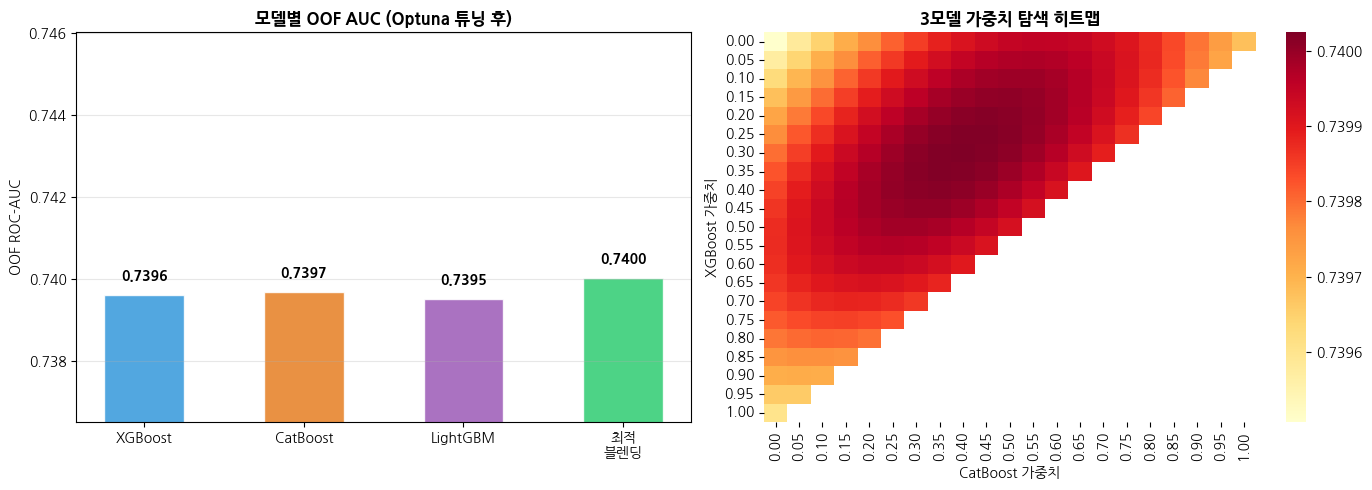


  모든 과정 완료! 🎉
  최종 OOF AUC  : 0.7400
  현재 리더보드  : 0.7416 (참고)


In [39]:
# ============================================================
# 10. 시각화
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_bar = ['XGBoost', 'CatBoost', 'LightGBM', '최적\n블렌딩']
aucs_bar   = [xgb_oof_auc, cat_oof_auc, lgb_oof_auc, best_auc_grid]
colors_bar = ['#3498db', '#e67e22', '#9b59b6', '#2ecc71']

bars = axes[0].bar(labels_bar, aucs_bar, color=colors_bar,
                   alpha=0.85, edgecolor='white', width=0.5)
for bar, a in zip(bars, aucs_bar):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
                 f'{a:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].set_ylim(min(aucs_bar) - 0.003, max(aucs_bar) + 0.006)
axes[0].set_ylabel('OOF ROC-AUC')
axes[0].set_title('모델별 OOF AUC (Optuna 튜닝 후)', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

hmap = np.full((len(np.arange(0, 1+step, step)),
                len(np.arange(0, 1+step, step))), np.nan)
for wx, wy, wz in candidates:
    i = round(wx / step)
    j = round(wy / step)
    hmap[i, j] = roc_auc_score(y, wx*oof_xgb + wy*oof_cat + wz*oof_lgb)

tick_labels = [f"{v:.2f}" for v in np.arange(0, 1+step, step)]
sns.heatmap(hmap, cmap="YlOrRd", annot=False,
            xticklabels=tick_labels, yticklabels=tick_labels, ax=axes[1])
axes[1].set_xlabel("CatBoost 가중치")
axes[1].set_ylabel("XGBoost 가중치")
axes[1].set_title("3모델 가중치 탐색 히트맵", fontweight='bold')

plt.tight_layout()
plt.show()

print("\n  모든 과정 완료! 🎉")
print(f"  최종 OOF AUC  : {results_submit[best_method][0]:.4f}")
print(f"  현재 리더보드  : 0.7416 (참고)")